In [2]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import neoscore as nsc

#new s3m loader
import s3m_loader as load_s3m

import importlib
from functools import reduce
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord, GCRS

from tqdm import tqdm

In [4]:
s3m = load_s3m.define_s3m("mba", verbose=True)  # defaults to pop="mba"

Search pattern: S1_*.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S1_00.s3m', './S1_01.s3m', './S1_02.s3m', './S1_03.s3m', './S1_04.s3m', './S1_05.s3m', './S1_06.s3m', './S1_07.s3m', './S1_08.s3m', './S1_09.s3m', './S1_10.s3m', './S1_11.s3m', './S1_12.s3m', './S1_13.s3m']
Loaded 14 file(s).
Final dataframe shape: (13883361, 15)
The final df is done.


In [5]:
s3m, array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = load_s3m.s3m_array(s3m)
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

In [6]:
neo = load_s3m.define_s3m(pop="neo")
neo, array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo = load_s3m.s3m_array(neo)
scorer_neo_s3m = nsc.NEOMODScorer(array4D_neo, H_center_neo, a_center_neo, e_center_neo, i_center_neo)

Search pattern: S0.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./S0.s3m']
Loaded 1 file(s).
Final dataframe shape: (268511, 15)
The final df is done.


In [7]:
tno = load_s3m.define_s3m(pop="tno")
tno, array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno = load_s3m.s3m_array(tno)
scorer_tno_s3m = nsc.NEOMODScorer(array4D_tno, H_center_tno, a_center_tno, e_center_tno, i_center_tno)

Search pattern: ST.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./ST.s3m']
Loaded 1 file(s).
Final dataframe shape: (48682, 15)
The final df is done.


In [8]:
trojan = load_s3m.define_s3m(pop="trojan")
trojan,array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn = load_s3m.s3m_array(trojan)
scorer_tjn_s3m = nsc.NEOMODScorer(array4D_tjn, H_center_tjn, a_center_tjn, e_center_tjn, i_center_tjn)

Search pattern: St5.s3m
Search dirs: ['.', 'S3Mdata']
Matched files: ['./St5.s3m']
Loaded 1 file(s).
Final dataframe shape: (179882, 15)
The final df is done.


In [9]:
obstime_str = "2025-03-21T00:00:00"
t_obs = Time(obstime_str, scale="tdb")

max_sep_deg = 30.0         
Nsample = None              

xlim = (-0.8, 0.8)
ylim = (-0.8, 0.8)
bins = 100                  

AU_km  = 149_597_870.7
mu_sun = 1.32712440018e11   # km^3/s^2


In [10]:
from scipy.spatial import cKDTree

# Grid / plotting window in ecliptic-rate space
xlim = (-0.8, 0.8)   # v_lambda range [deg/day]
ylim = (-0.8, 0.8)   # v_beta   range [deg/day]

# Uniform grid spacing
# 0.01 as grid step
grid_step = 0.01

# Grid coordinates
x_grid = np.arange(xlim[0], xlim[1] + grid_step, grid_step)
y_grid = np.arange(ylim[0], ylim[1] + grid_step, grid_step)

# 2D mesh of evaluation points
X0, Y0 = np.meshgrid(x_grid, y_grid, indexing="xy")

# Flattened list of evaluation points: shape (Ngrid, 2)
grid_points = np.column_stack([X0.ravel(), Y0.ravel()])

print("Grid shape:", X0.shape)
print("Number of evaluation points:", len(grid_points))

Grid shape: (161, 161)
Number of evaluation points: 25921


In [11]:
from math import lgamma
# Based on Appendix B posterior in 2D for one evaluation point

def log_posterior_d0_2d(d0_grid, d_knn):
    """
    Compute the unnormalized log-posterior log p(d0 | d_1,...,d_N)
    for the 2D Appendix B nearest-neighbor Bayesian density estimator.

    Parameters
    ----------
    d0_grid : ndarray, shape (M,)
        Trial values of d0 (local spacing) at which to evaluate the posterior.
        Must be strictly positive.
    d_knn : ndarray, shape (N,)
        Sorted nearest-neighbor distances d_1,...,d_N.

    Returns
    -------
    logp : ndarray, shape (M,)
        Unnormalized log-posterior values on d0_grid.
    """
    # Small d0 = points close to each other, big d0 = points sparse
    d0_grid = np.asarray(d0_grid, dtype=float)
    d_knn = np.asarray(d_knn, dtype=float)

    if np.any(d0_grid <= 0):
        raise ValueError("All d0_grid values must be > 0.")
    if np.any(d_knn <= 0):
        raise ValueError("All nearest-neighbor distances must be > 0.")

    N = len(d_knn)
    k_vals = np.arange(1, N + 1)

    logp = np.zeros_like(d0_grid, dtype=float)

    for i, d0 in enumerate(d0_grid):
        term_sum = 0.0

        for k, dk in zip(k_vals, d_knn):
            # log of:
            # 2 / [ d0 (k-1)! ] * exp(-(dk/d0)^2) * (dk/d0)^(2k-1)
            term = (
                np.log(2.0)
                - np.log(d0)
                - lgamma(k)                      # log((k-1)!)
                - (dk / d0) ** 2
                + (2 * k - 1) * np.log(dk / d0)
            )
            term_sum += term

        logp[i] = term_sum

    return logp


# Normalize posterior sampled on a d0 grid

def normalize_posterior_from_loggrid(d0_grid, logp):
    """
    Normalize a posterior sampled on a d0 grid.

    Parameters
    ----------
    d0_grid : ndarray
        Grid of d0 values.
    logp : ndarray
        Unnormalized log-posterior evaluated on d0_grid.

    Returns
    -------
    p_norm : ndarray
        Normalized posterior p(d0 | data) on the grid,
        such that integral p_norm dd0 = 1.
    """
    d0_grid = np.asarray(d0_grid, dtype=float)
    logp = np.asarray(logp, dtype=float)

    # shift by max for numerical stability
    logp_shift = logp - np.max(logp)
    p_unnorm = np.exp(logp_shift)

    # normalize by trapezoid rule
    norm = np.trapz(p_unnorm, d0_grid)
    if norm <= 0 or not np.isfinite(norm):
        raise ValueError("Posterior normalization failed.")

    p_norm = p_unnorm / norm
    return p_norm


In [12]:
#Get nearest-neighbor distances for any tree

def get_knn_distances(tree, x0, y0, k=10):
    """
    Return distances from evaluation point (x0, y0)
    to its k nearest neighbors in the given KD-tree.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from a population's (v_lambda, v_beta) points.
    x0, y0 : float
        Evaluation point coordinates.
    k : int
        Number of nearest neighbors.

    Returns
    -------
    d : ndarray, shape (k,)
        Sorted nearest-neighbor distances.
    idx : ndarray, shape (k,)
        Indices of those neighbors in the original point array.
    """
    q = np.array([[x0, y0]])
    d, idx = tree.query(q, k=k)
    return d[0], idx[0]

In [13]:
# Full-posterior density estimate at one evaluation point

def estimate_density_full_posterior_2d(
    tree,
    x0,
    y0,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=800,
    return_diagnostics=False,
):
    """
    Estimate local 2D density at one evaluation point (x0, y0)
    using the full Appendix B posterior.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points in (v_lambda, v_beta).
    x0, y0 : float
        Evaluation point coordinates.
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor : float, default=5.0
        Lower d0 grid bound is d_1 / d0_min_factor.
    d0_max_factor : float, default=10.0
        Upper d0 grid bound is d_k * d0_max_factor.
    n_d0_grid : int, default=800
        Number of trial d0 points in the posterior grid.
    return_diagnostics : bool, default=False
        If True, also return diagnostic quantities.

    Returns
    -------
    n0_mean : float
        Posterior mean density <n0>.
    
    If return_diagnostics=True, also returns a dict with:
        d_knn, d0_grid, p_d0, d0_map, d0_mean, n0_map, n0_mean
    """
    # nearest-neighbor distances
    d_knn, idx_knn = get_knn_distances(tree, x0, y0, k=k)

    # build d0 grid
    d0_min = d_knn[0] / d0_min_factor
    d0_max = d_knn[-1] * d0_max_factor
    d0_grid = np.logspace(np.log10(d0_min), np.log10(d0_max), n_d0_grid)

    # posterior in d0
    logp_d0 = log_posterior_d0_2d(d0_grid, d_knn)
    p_d0 = normalize_posterior_from_loggrid(d0_grid, logp_d0)

    # convert to density n0 = 1 / (pi d0^2)
    n0_grid = 1.0 / (np.pi * d0_grid**2)

   
    d0_map = d0_grid[np.argmax(p_d0)]
    d0_mean = np.trapz(d0_grid * p_d0, d0_grid)
    n0_map = 1.0 / (np.pi * d0_map**2)
    n0_mean = np.trapz(n0_grid * p_d0, d0_grid)

    if return_diagnostics:
        diag = {
            "d_knn": d_knn,
            "d0_grid": d0_grid,
            "p_d0": p_d0,
            "d0_map": d0_map,
            "d0_mean": d0_mean,
            "n0_map": n0_map,
            "n0_mean": n0_mean,
        }
        return n0_mean, diag

    return n0_mean

In [14]:
# Evaluate full-posterior density on the whole grid

from tqdm import tqdm

def evaluate_density_map_full_posterior_2d(
    tree,
    grid_points,
    k=10,
    d0_min_factor=5.0,
    d0_max_factor=10.0,
    n_d0_grid=400,
    show_progress=True,
):
    """
    Evaluate posterior-mean density on a full set of evaluation points.

    Parameters
    ----------
    tree : scipy.spatial.cKDTree
        KD-tree built from the population points.
    grid_points : ndarray, shape (Ngrid, 2)
        Evaluation points [(x0,y0), ...].
    k : int, default=10
        Number of nearest neighbors.
    d0_min_factor, d0_max_factor : float
        Factors setting the d0 grid range for each evaluation point.
    n_d0_grid : int, default=400
        Number of d0 samples per evaluation point.
        Use 400 for a first full-map test; increase later if needed.
    show_progress : bool, default=True
        Show tqdm progress bar.

    Returns
    -------
    density_vals : ndarray, shape (Ngrid,)
        Posterior mean density at each evaluation point.
    """
    density_vals = np.empty(len(grid_points), dtype=float)

    iterator = enumerate(grid_points)
    if show_progress:
        iterator = tqdm(iterator, total=len(grid_points), desc="Evaluating density map")

    for i, (x0, y0) in iterator:
        density_vals[i] = estimate_density_full_posterior_2d(
            tree,
            x0,
            y0,
            k=k,
            d0_min_factor=d0_min_factor,
            d0_max_factor=d0_max_factor,
            n_d0_grid=n_d0_grid,
            return_diagnostics=False,
        )

    return density_vals

In [15]:
k_map = 10
n_d0_grid_map = 400

In [16]:
# Population dataframes for cloning / per-population workflows
s3m_mba = s3m
s3m_neo = neo
s3m_tno = tno
s3m_tjn = trojan  

In [17]:

# Clone a population by randomizing mean anomaly at obstime

import gc
import numpy as np
from scipy.spatial import cKDTree
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, GCRS, get_sun

AU_km = 149_597_870.7
mu_sun = 1.32712440018e11  # km^3/s^2

def clone_population_random_mean_anomaly(df, clone_factor, obstime_str, rng=None):
    """
    Clone each orbit clone_factor times by assigning a random mean anomaly
    at obstime_str. Keeps a,e,i,node,argperi fixed and changes only orbital phase
    via t_p.

    Returns repeated orbital element arrays.
    """
    if rng is None:
        rng = np.random.default_rng(0)

    t_obs = Time(obstime_str, scale="tdb")

    a_AU   = df["a"].to_numpy(dtype=np.float32)
    e      = df["e"].to_numpy(dtype=np.float32)
    inc    = df["i"].to_numpy(dtype=np.float32)
    raan   = df["node"].to_numpy(dtype=np.float32)
    argp   = df["argperi"].to_numpy(dtype=np.float32)

    # repeat fixed elements
    a_rep    = np.repeat(a_AU, clone_factor).astype(np.float32)
    e_rep    = np.repeat(e, clone_factor).astype(np.float32)
    inc_rep  = np.repeat(inc, clone_factor).astype(np.float32)
    raan_rep = np.repeat(raan, clone_factor).astype(np.float32)
    argp_rep = np.repeat(argp, clone_factor).astype(np.float32)

    # mean motion in rad/day
    a_km = a_rep.astype(np.float64) * AU_km
    n_rad_s = np.sqrt(mu_sun / (a_km**3))
    n_rad_day = n_rad_s * 86400.0

    # random mean anomaly at observation epoch
    M_rand = rng.uniform(0.0, 2.0*np.pi, size=len(a_rep)).astype(np.float64)

    # choose perihelion time so that M(obstime)=M_rand
    tp_new = (t_obs.mjd - (M_rand / n_rad_day)).astype(np.float32)

    return a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new

In [18]:
# Convert orbital elements -> vlam, vbeta using existing pipeline
# but with a configurable sky center in ecliptic lon/lat

def elements_to_vlam_vbeta(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_mode="custom_ecliptic",   # "custom_ecliptic" or "antisun"
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    import astropy.units as u
    from astropy.time import Time
    from astropy.coordinates import (
        SkyCoord, GCRS, get_sun, GeocentricTrueEcliptic
    )

    t_obs = Time(obstime_str, scale="tdb")

    # heliocentric ecliptic state
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    # RA/Dec and RA/Dec rates
    x, y, z = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        (rho2 > 0) & np.isfinite(r2) & (r2 > 0)
    )

    ra_deg  = (np.rad2deg(ra[good]) % 360.0)
    dec_deg = np.rad2deg(dec[good])
    dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    # object sky coords in GCRS
    sc = SkyCoord(ra=ra_deg*u.deg, dec=dec_deg*u.deg, frame=GCRS(obstime=t_obs))

    # choose center of the sky cut
    if center_mode == "antisun":
        sun_gcrs = get_sun(t_obs).transform_to(GCRS(obstime=t_obs))
        center_sc = SkyCoord(
            x=-sun_gcrs.cartesian.x,
            y=-sun_gcrs.cartesian.y,
            z=-sun_gcrs.cartesian.z,
            representation_type="cartesian",
            frame=GCRS(obstime=t_obs),
        )
    elif center_mode == "custom_ecliptic":
        center_ecl = SkyCoord(
            lon=center_lon_deg * u.deg,
            lat=center_lat_deg * u.deg,
            distance=1.0 * u.AU,
            frame=GeocentricTrueEcliptic(obstime=t_obs),
        )
        center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))
    else:
        raise ValueError("center_mode must be 'antisun' or 'custom_ecliptic'")

    sep = sc.separation(center_sc).deg

    m = sep <= max_sep_deg
    ra_deg, dec_deg = ra_deg[m], dec_deg[m]
    dra_deg_day, ddec_deg_day = dra_deg_day[m], ddec_deg_day[m]

    # RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg, dec_deg,
        dra_deg_day, ddec_deg_day,
        obstime_str
    )

    finite = np.isfinite(vlam) & np.isfinite(vbeta)
    vlam = vlam[finite].astype(np.float32)
    vbeta = vbeta[finite].astype(np.float32)

    return vlam, vbeta

In [19]:

# Clone configuration (less memory intensive)

clone_sources = {
    "MBA": {
        "df": s3m,
        "scorer": scorer_mba_s3m,
        "clone_factor": 1,   # first test: no MBA cloning yet
        "scatter_size": 1,
        "scatter_alpha": 0.05,
    },
    "NEO": {
        "df": neo,
        "scorer": scorer_neo_s3m,
        "clone_factor": 10,
        "scatter_size": 4,
        "scatter_alpha": 0.08,
    },
    "TNO": {
        "df": tno,
        "scorer": scorer_tno_s3m,
        "clone_factor": 10,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
    "Trojans": {
        "df": trojan,
        "scorer": scorer_tjn_s3m,
        "clone_factor": 10,
        "scatter_size": 6,
        "scatter_alpha": 0.10,
    },
}

rng = np.random.default_rng(42)
overlay_max = 100_000

In [20]:
# Build cloned rate-space populations one at a time
# Keeps only small overlay samples + final maps

clone_overlay = {}
clone_density_maps = {}
clone_density_maps_downweighted = {}

for pop_name, info in clone_sources.items():
    f = info["clone_factor"]
    df = info["df"]

    print(f"\nCloning {pop_name} with factor {f}...")

    a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
        df, clone_factor=f, obstime_str=obstime_str, rng=rng
    )
    print("  cloned orbit count:", len(a_rep))

    vlam_clone, vbeta_clone = elements_to_vlam_vbeta(
        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
        obstime_str=obstime_str,
        scorer=info["scorer"],
        max_sep_deg=max_sep_deg,
        chunk=100_000,
        show_progress=True,
    )
    print(f"  final cloned visible points: {len(vlam_clone)}")

    # raw element arrays no longer needed
    del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
    gc.collect()

    # keep only a small random subset for plotting overlays
    n_overlay = min(overlay_max, len(vlam_clone))
    idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)
    clone_overlay[pop_name] = {
        "vlam": vlam_clone[idx_overlay].copy(),
        "vbeta": vbeta_clone[idx_overlay].copy(),
        "scatter_size": info["scatter_size"],
        "scatter_alpha": info["scatter_alpha"],
    }

    pts_clone = np.column_stack([vlam_clone, vbeta_clone])
    tree_clone = cKDTree(pts_clone)

    density_clone_flat = evaluate_density_map_full_posterior_2d(
        tree_clone,
        grid_points,
        k=k_map,
        n_d0_grid=n_d0_grid_map,
        show_progress=True,
    )

    density_clone_map = density_clone_flat.reshape(X0.shape)
    density_downweighted_map = density_clone_map / f

    clone_density_maps[pop_name] = density_clone_map
    clone_density_maps_downweighted[pop_name] = density_downweighted_map

    print(f"{pop_name} done.")
    print("  raw cloned max density   :", np.nanmax(density_clone_map))
    print("  downweighted max density :", np.nanmax(density_downweighted_map))

    # cleanup large arrays before next population
    del vlam_clone, vbeta_clone, pts_clone, tree_clone, density_clone_flat
    gc.collect()


Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 13.02it/s]


  final cloned visible points: 1418518


Evaluating density map: 100%|██████████| 25921/25921 [08:08<00:00, 53.04it/s]


MBA done.
  raw cloned max density   : 393660850.11085695
  downweighted max density : 393660850.11085695

Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 4990382200.988374
  downweighted max density : 499038220.0988374

Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 13.49it/s]


  final cloned visible points: 221533


Evaluating density map: 100%|██████████| 25921/25921 [08:02<00:00, 53.68it/s]


Trojans done.
  raw cloned max density   : 228962399.01238662
  downweighted max density : 22896239.90123866


In [21]:
def build_cloned_maps_for_center(
    center_lon_deg,
    center_lat_deg,
    center_label,
    clone_sources,
    obstime_str,
    max_sep_deg,
    rng,
    overlay_max,
    grid_points,
    X0,
    k_map,
    n_d0_grid_map,
):
    clone_overlay = {}
    clone_density_maps = {}
    clone_density_maps_downweighted = {}

    for pop_name, info in clone_sources.items():
        f = info["clone_factor"]
        df = info["df"]

        print(f"\n[{center_label}] Cloning {pop_name} with factor {f}...")

        a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
            df, clone_factor=f, obstime_str=obstime_str, rng=rng
        )
        print("  cloned orbit count:", len(a_rep))

        vlam_clone, vbeta_clone = elements_to_vlam_vbeta(
            a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new,
            obstime_str=obstime_str,
            scorer=info["scorer"],
            max_sep_deg=max_sep_deg,
            chunk=100_000,
            show_progress=True,
            center_mode="custom_ecliptic",
            center_lon_deg=center_lon_deg,
            center_lat_deg=center_lat_deg,
        )
        print(f"  final cloned visible points: {len(vlam_clone)}")

        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
        gc.collect()

        n_overlay = min(overlay_max, len(vlam_clone))
        idx_overlay = rng.choice(len(vlam_clone), size=n_overlay, replace=False)

        clone_overlay[pop_name] = {
            "vlam": vlam_clone[idx_overlay].copy(),
            "vbeta": vbeta_clone[idx_overlay].copy(),
            "scatter_size": info["scatter_size"],
            "scatter_alpha": info["scatter_alpha"],
        }

        pts_clone = np.column_stack([vlam_clone, vbeta_clone])
        tree_clone = cKDTree(pts_clone)

        density_clone_flat = evaluate_density_map_full_posterior_2d(
            tree_clone,
            grid_points,
            k=k_map,
            n_d0_grid=n_d0_grid_map,
            show_progress=True,
        )

        density_clone_map = density_clone_flat.reshape(X0.shape)
        density_downweighted_map = density_clone_map / f

        clone_density_maps[pop_name] = density_clone_map
        clone_density_maps_downweighted[pop_name] = density_downweighted_map

        print(f"{pop_name} done.")
        print("  raw cloned max density   :", np.nanmax(density_clone_map))
        print("  downweighted max density :", np.nanmax(density_downweighted_map))

        del vlam_clone, vbeta_clone, pts_clone, tree_clone, density_clone_flat
        gc.collect()

    density_all_clone_downweighted = (
        clone_density_maps_downweighted["MBA"] +
        clone_density_maps_downweighted["NEO"] +
        clone_density_maps_downweighted["TNO"] +
        clone_density_maps_downweighted["Trojans"]
    )

    return {
        "label": center_label,
        "center_lon_deg": center_lon_deg,
        "center_lat_deg": center_lat_deg,
        "overlay": clone_overlay,
        "density_maps": clone_density_maps,
        "density_maps_downweighted": clone_density_maps_downweighted,
        "density_all_downweighted": density_all_clone_downweighted,
    }

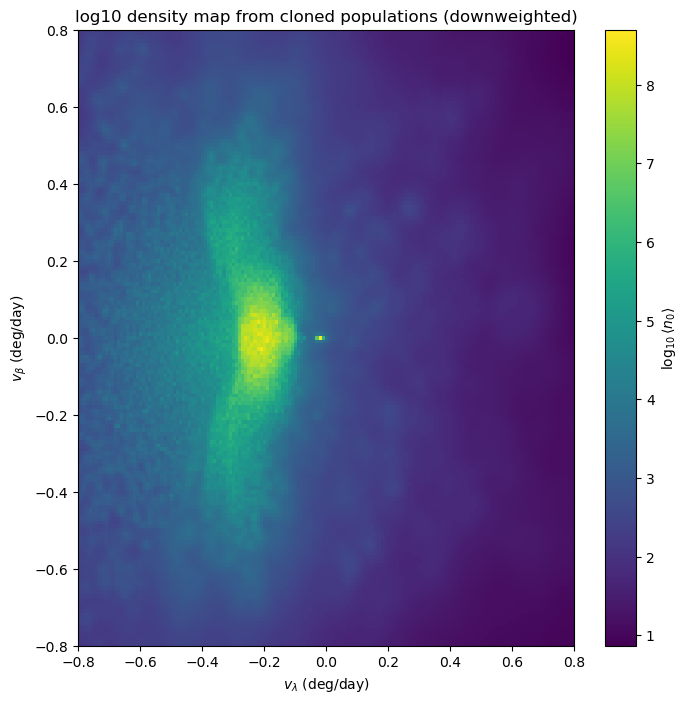

In [22]:

# Combined ALL map from downweighted cloned populations

density_all_clone_downweighted = (
    clone_density_maps_downweighted["MBA"] +
    clone_density_maps_downweighted["NEO"] +
    clone_density_maps_downweighted["TNO"] +
    clone_density_maps_downweighted["Trojans"]
)

log_density_all_clone_downweighted = np.log10(
    np.maximum(density_all_clone_downweighted, 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("log10 density map from cloned populations (downweighted)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

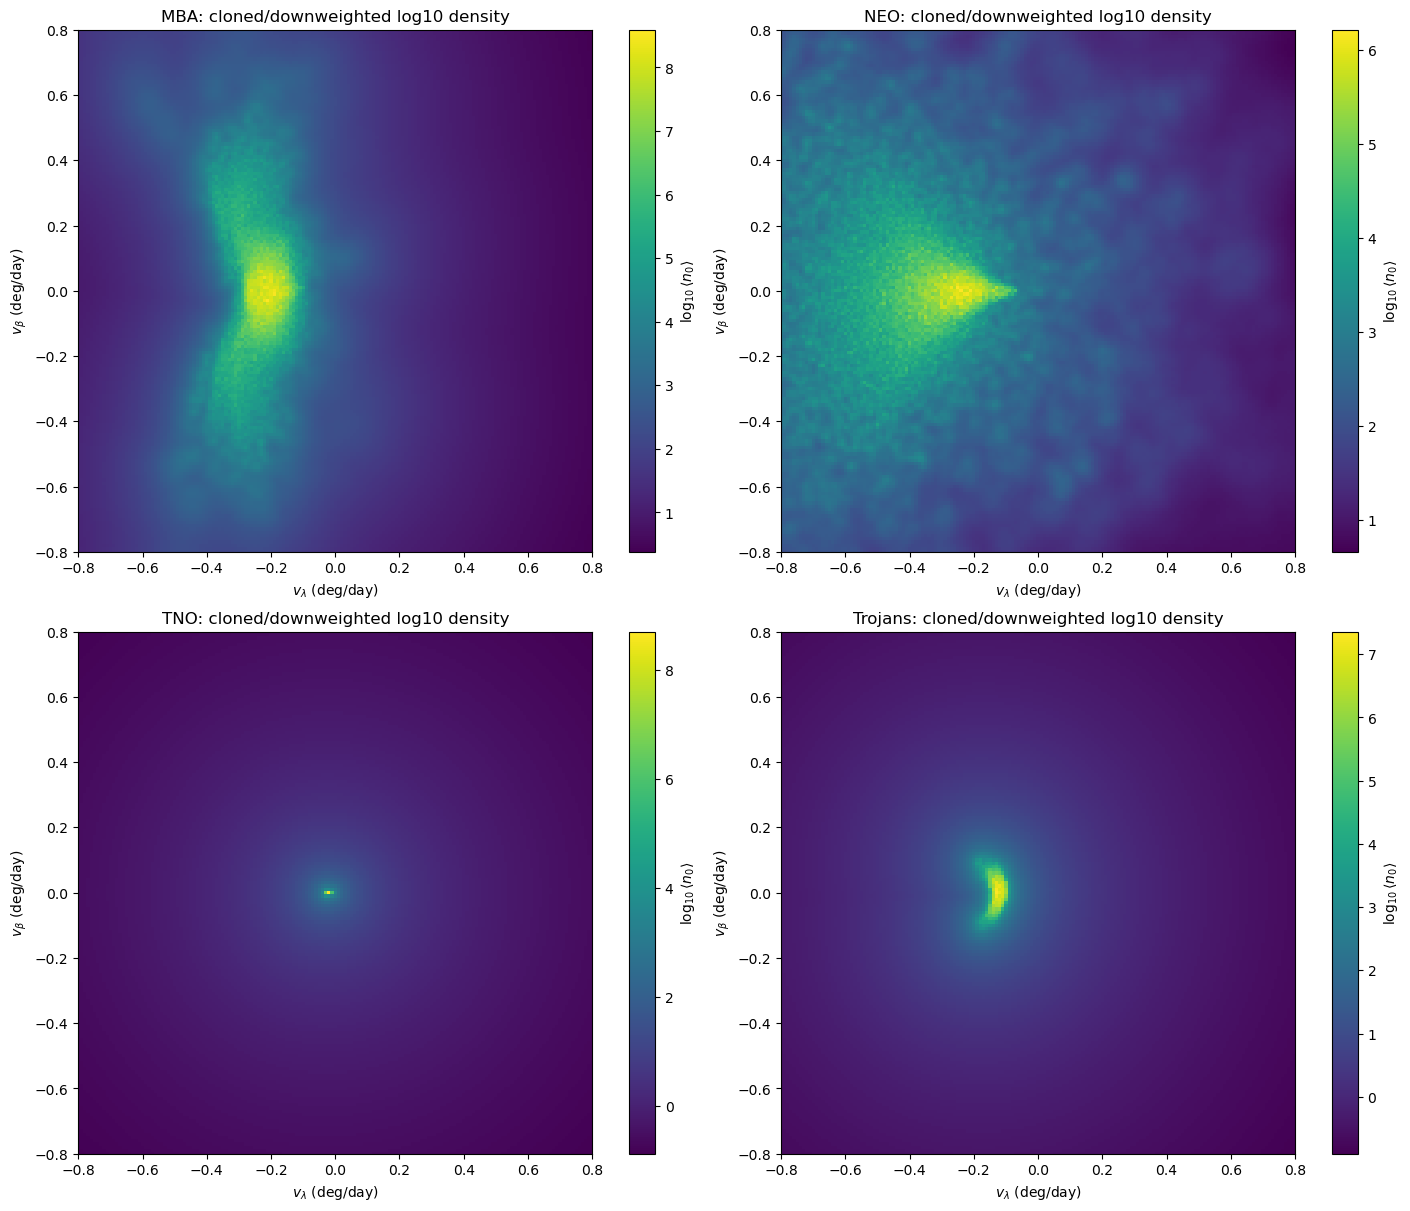

In [23]:

# Plot all 4 cloned/downweighted log-density maps

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, clone_density_maps_downweighted.keys()):
    log_map = np.log10(np.maximum(clone_density_maps_downweighted[pop_name], 1e-30))

    im = ax.pcolormesh(
        X0, Y0, log_map,
        shading="auto"
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

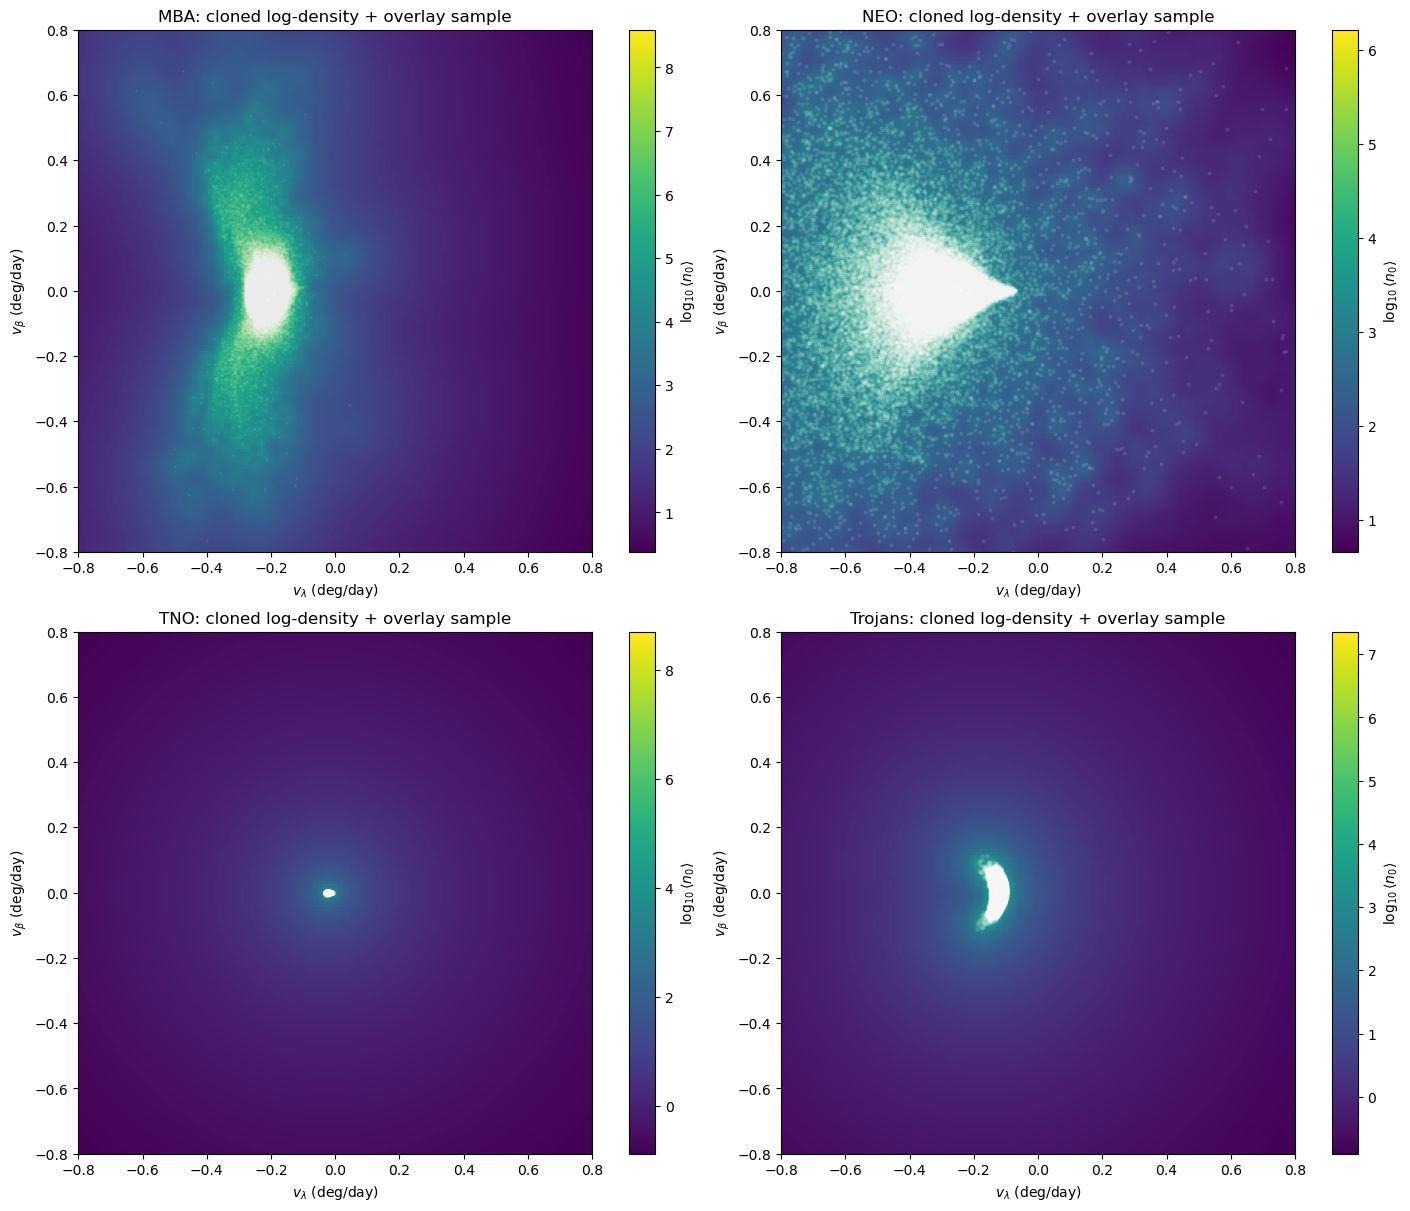

In [24]:

# Plot all 4 cloned/downweighted maps with overlay samples

fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, clone_density_maps_downweighted.keys()):
    log_map = np.log10(np.maximum(clone_density_maps_downweighted[pop_name], 1e-30))
    overlay = clone_overlay[pop_name]

    im = ax.pcolormesh(
        X0, Y0, log_map,
        shading="auto"
    )

    ax.scatter(
        overlay["vlam"],
        overlay["vbeta"],
        s=overlay["scatter_size"],
        alpha=overlay["scatter_alpha"],
        color="white",
        rasterized=True,
    )

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned log-density + overlay sample")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [25]:
rng = np.random.default_rng(42)

result_lon180_lat10 = build_cloned_maps_for_center(
    center_lon_deg=180.0,
    center_lat_deg=10.0,
    center_label="lon180_lat10",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=rng,
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)

result_lon180_lat30 = build_cloned_maps_for_center(
    center_lon_deg=180.0,
    center_lat_deg=30.0,
    center_label="lon180_lat30",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=rng,
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon180_lat10] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 13.38it/s]


  final cloned visible points: 1334072


Evaluating density map: 100%|██████████| 25921/25921 [07:57<00:00, 54.32it/s]


MBA done.
  raw cloned max density   : 306585436.49302816
  downweighted max density : 306585436.49302816

[lon180_lat10] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 2175234687.5613008
  downweighted max density : 217523468.75613007

[lon180_lat30] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 13.78it/s]


  final cloned visible points: 96072


Evaluating density map: 100%|██████████| 25921/25921 [08:03<00:00, 53.65it/s]


Trojans done.
  raw cloned max density   : 127583510.47547698
  downweighted max density : 12758351.047547698


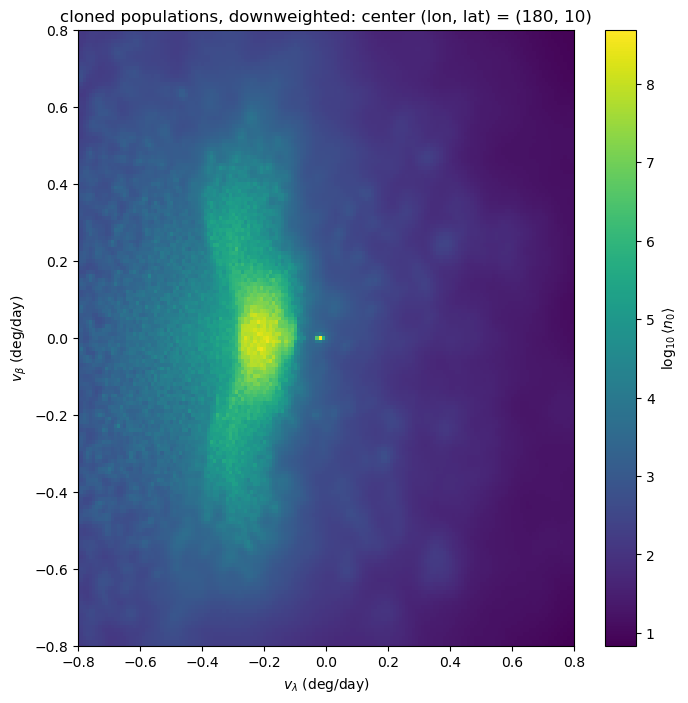

In [26]:
log_density_all_clone_downweighted = np.log10(
    np.maximum(result_lon180_lat10["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("cloned populations, downweighted: center (lon, lat) = (180, 10)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

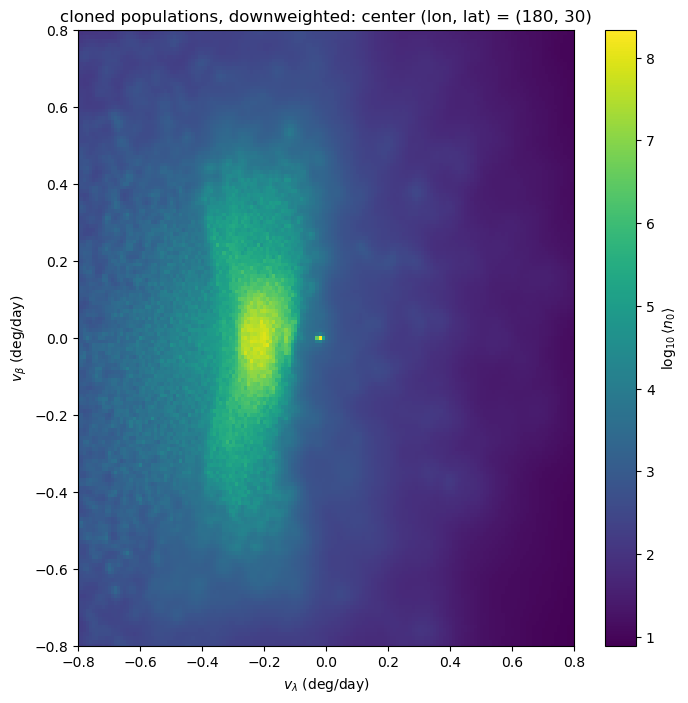

In [27]:
log_density_all_clone_downweighted = np.log10(
    np.maximum(result_lon180_lat30["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("cloned populations, downweighted: center (lon, lat) = (180, 30)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

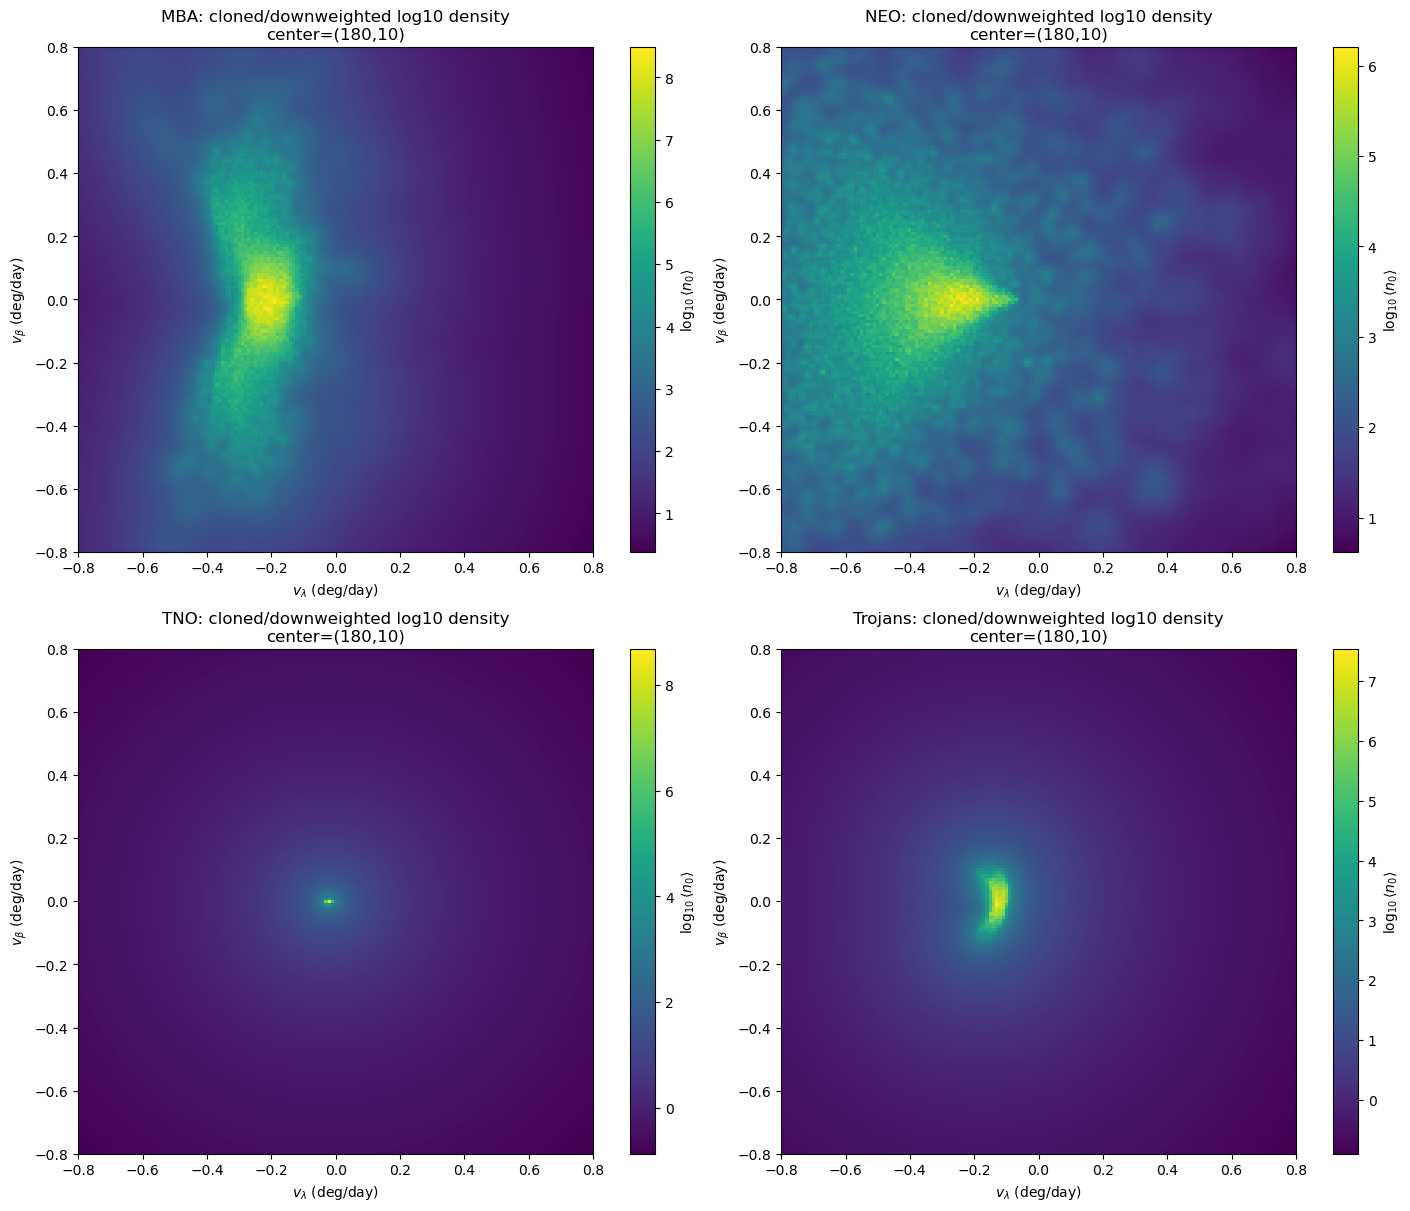

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = result_lon180_lat10["density_maps_downweighted"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density\ncenter=(180,10)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

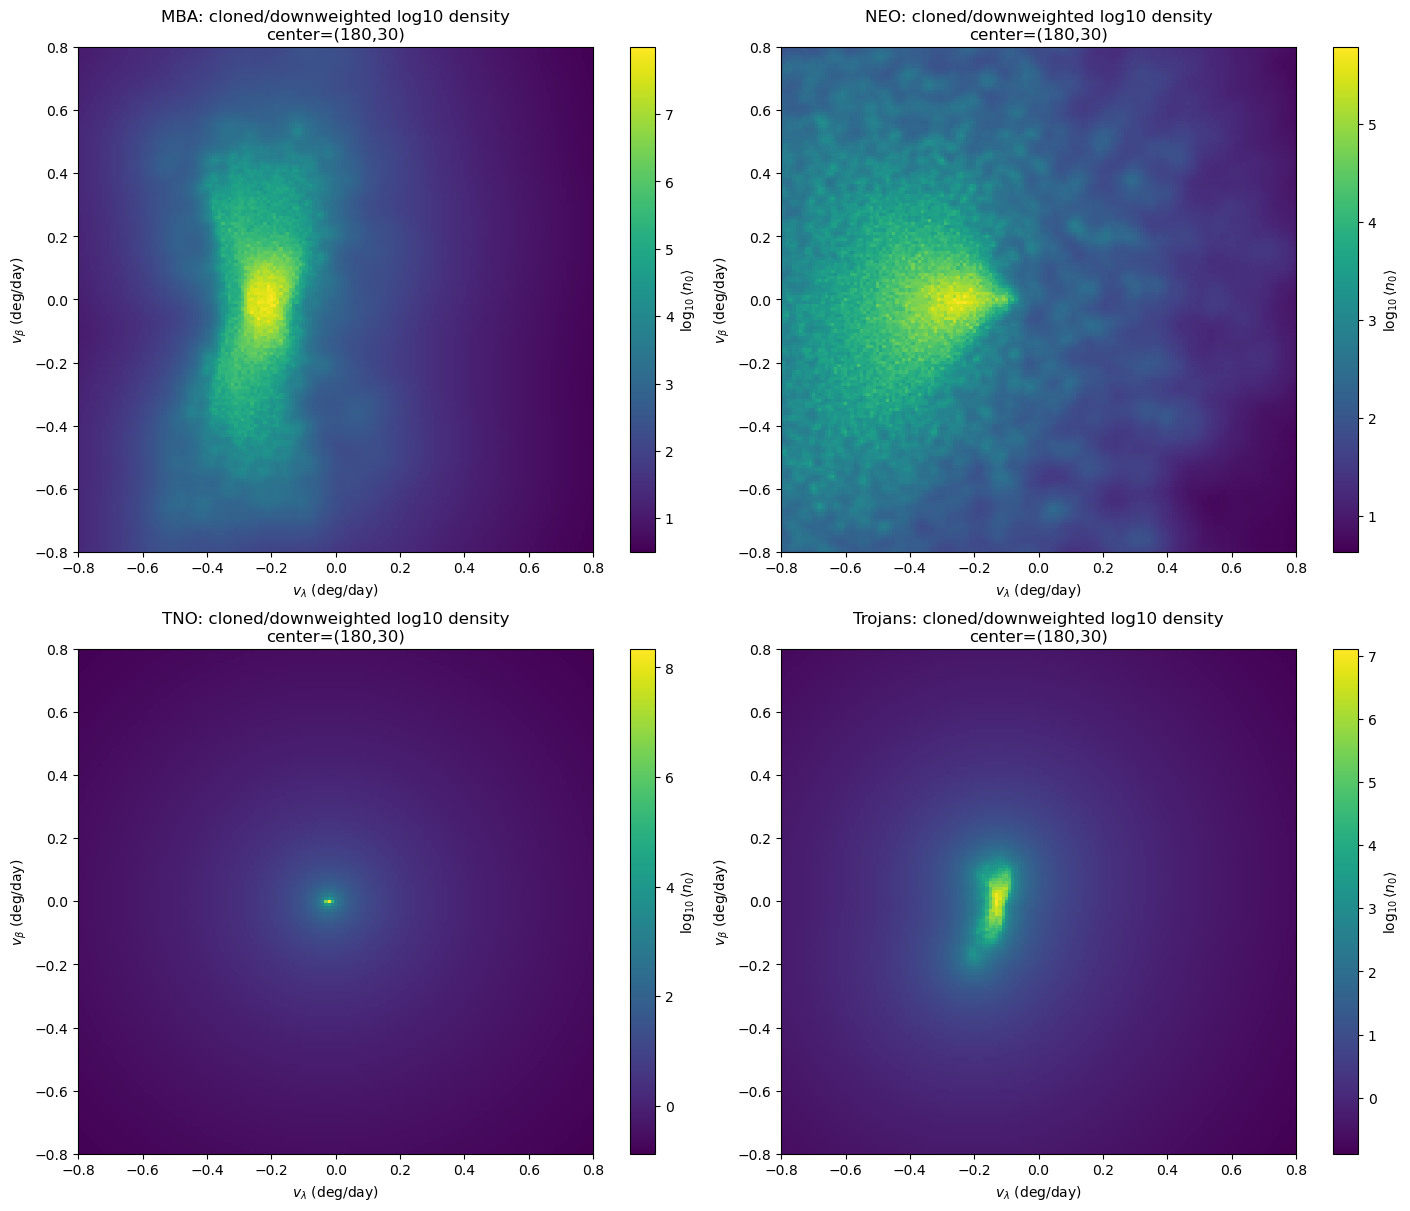

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = result_lon180_lat30["density_maps_downweighted"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density\ncenter=(180,30)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [30]:
result_lon150_lat0 = build_cloned_maps_for_center(
    center_lon_deg=150.0,
    center_lat_deg=0.0,
    center_label="lon150_lat0",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)




[lon150_lat0] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 13.07it/s]


  final cloned visible points: 1524070


Evaluating density map: 100%|██████████| 25921/25921 [08:06<00:00, 53.25it/s]


MBA done.
  raw cloned max density   : 147520653.0221452
  downweighted max density : 147520653.0221452

[lon150_lat0] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 3701861149.986479
  downweighted max density : 370186114.99864787

[lon150_lat0] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 13.74it/s]


  final cloned visible points: 226407


Evaluating density map: 100%|██████████| 25921/25921 [08:03<00:00, 53.59it/s]


Trojans done.
  raw cloned max density   : 249133628.5026696
  downweighted max density : 24913362.85026696


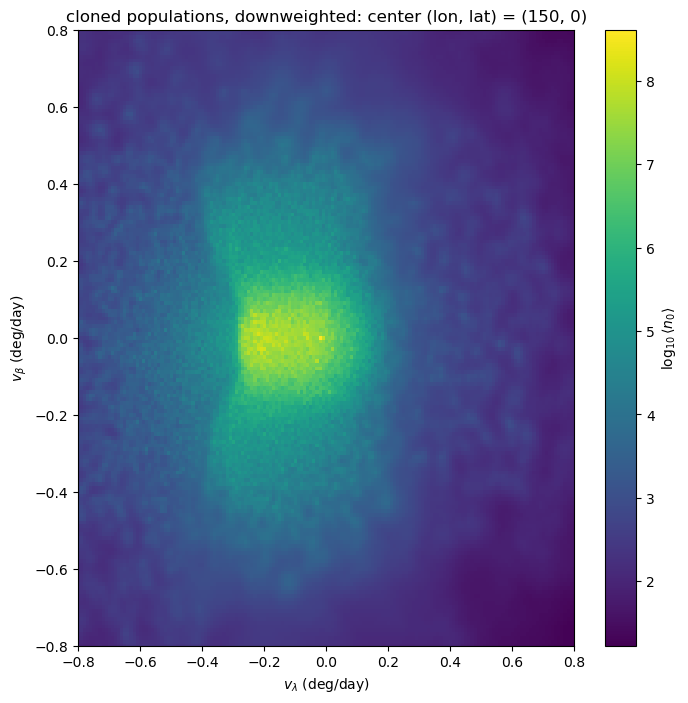

In [31]:
log_density_all_clone_downweighted = np.log10(
    np.maximum(result_lon150_lat0["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("cloned populations, downweighted: center (lon, lat) = (150, 0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

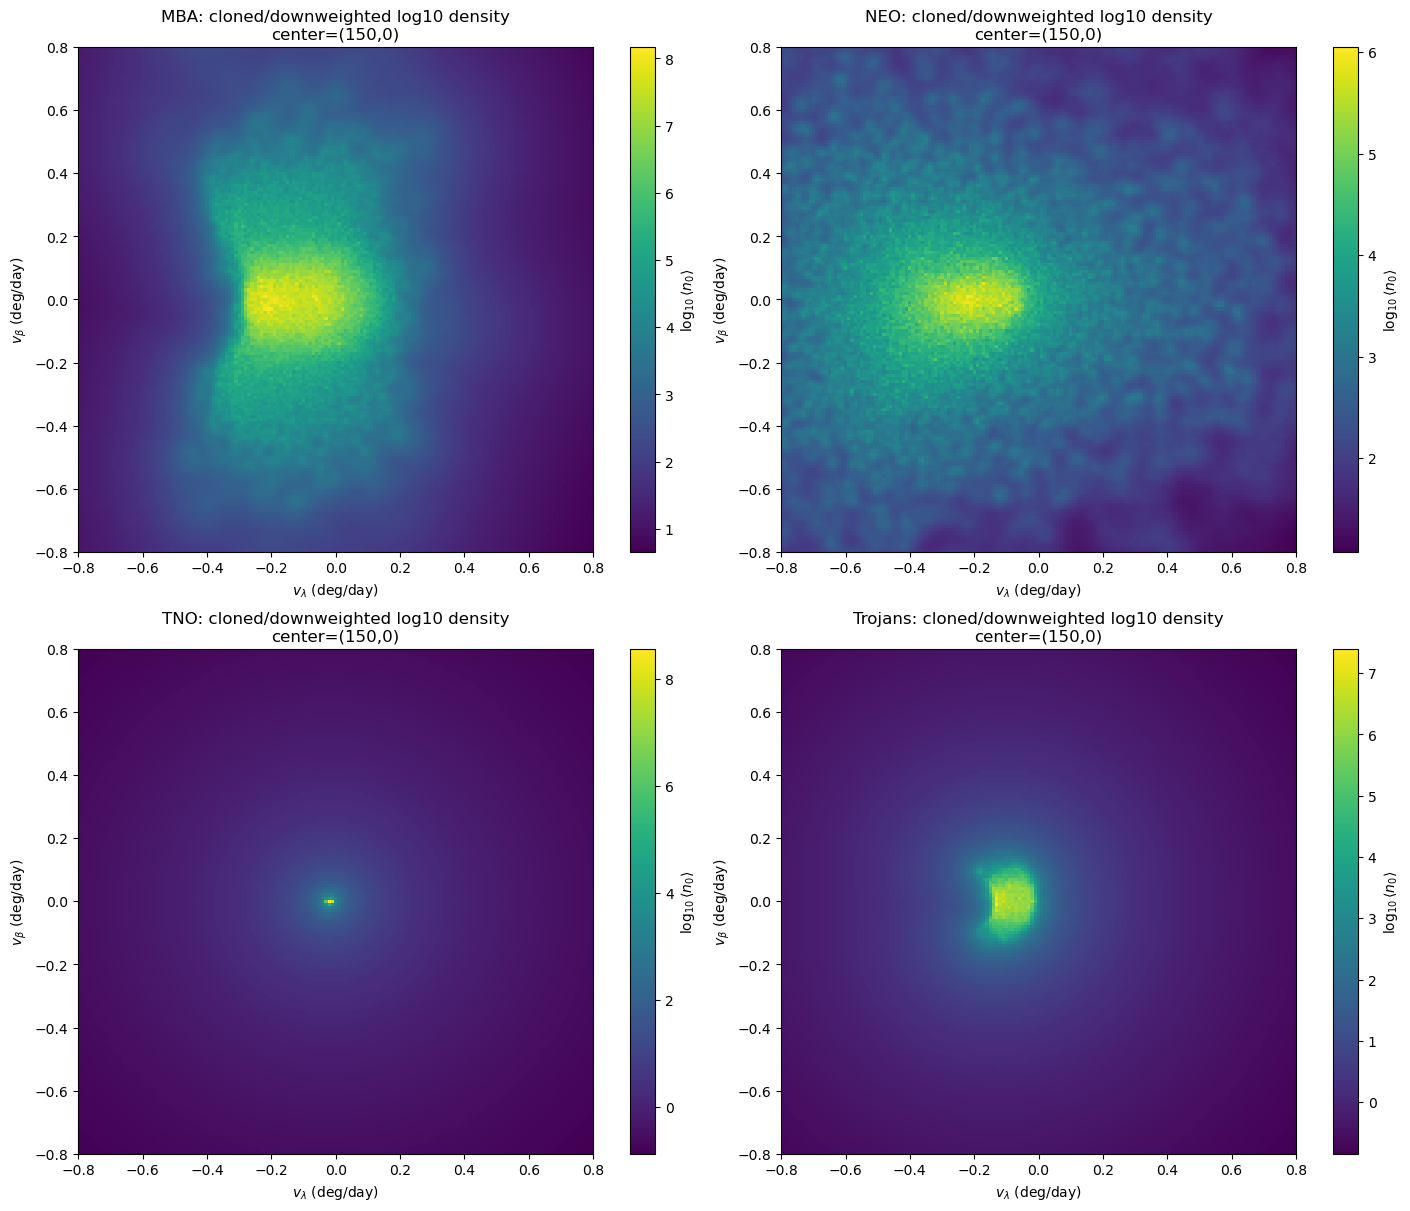

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = result_lon150_lat0["density_maps_downweighted"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density\ncenter=(150,0)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [33]:
result_lon120_lat0 = build_cloned_maps_for_center(
    center_lon_deg=120.0,
    center_lat_deg=0.0,
    center_label="lon120_lat0",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon120_lat0] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 13.15it/s]


  final cloned visible points: 1812578


Evaluating density map: 100%|██████████| 25921/25921 [07:57<00:00, 54.25it/s]


MBA done.
  raw cloned max density   : 112811774.78064577
  downweighted max density : 112811774.78064577

[lon120_lat0] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 846439159.5391991
  downweighted max density : 84643915.95391992

[lon120_lat0] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 13.26it/s]


  final cloned visible points: 242985


Evaluating density map: 100%|██████████| 25921/25921 [08:03<00:00, 53.61it/s]


Trojans done.
  raw cloned max density   : 51847504.5068283
  downweighted max density : 5184750.45068283


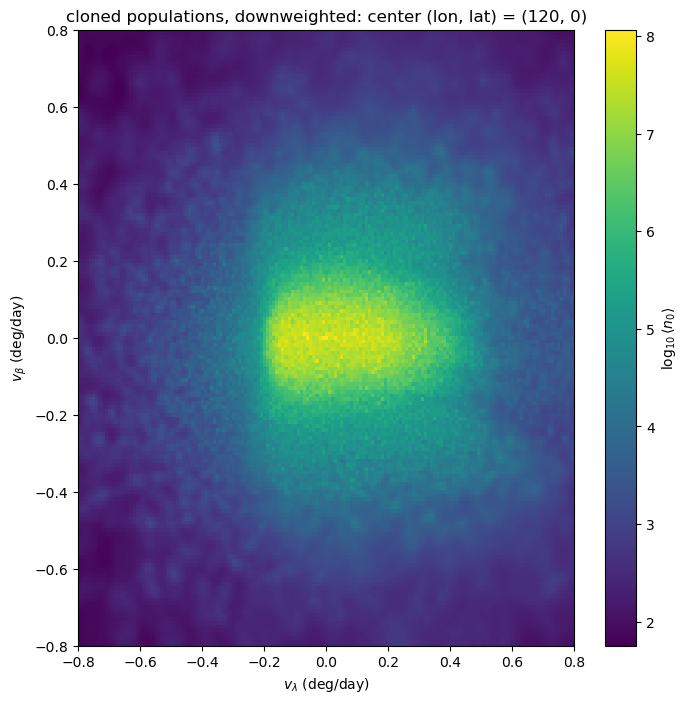

In [34]:
log_density_all_clone_downweighted = np.log10(
    np.maximum(result_lon120_lat0["density_all_downweighted"], 1e-30)
)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.pcolormesh(X0, Y0, log_density_all_clone_downweighted, shading="auto")

ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_xlabel(r"$v_\lambda$ (deg/day)")
ax.set_ylabel(r"$v_\beta$ (deg/day)")
ax.set_title("cloned populations, downweighted: center (lon, lat) = (120, 0)")
fig.colorbar(im, ax=ax, label=r"$\log_{10}\langle n_0 \rangle$")

plt.show()

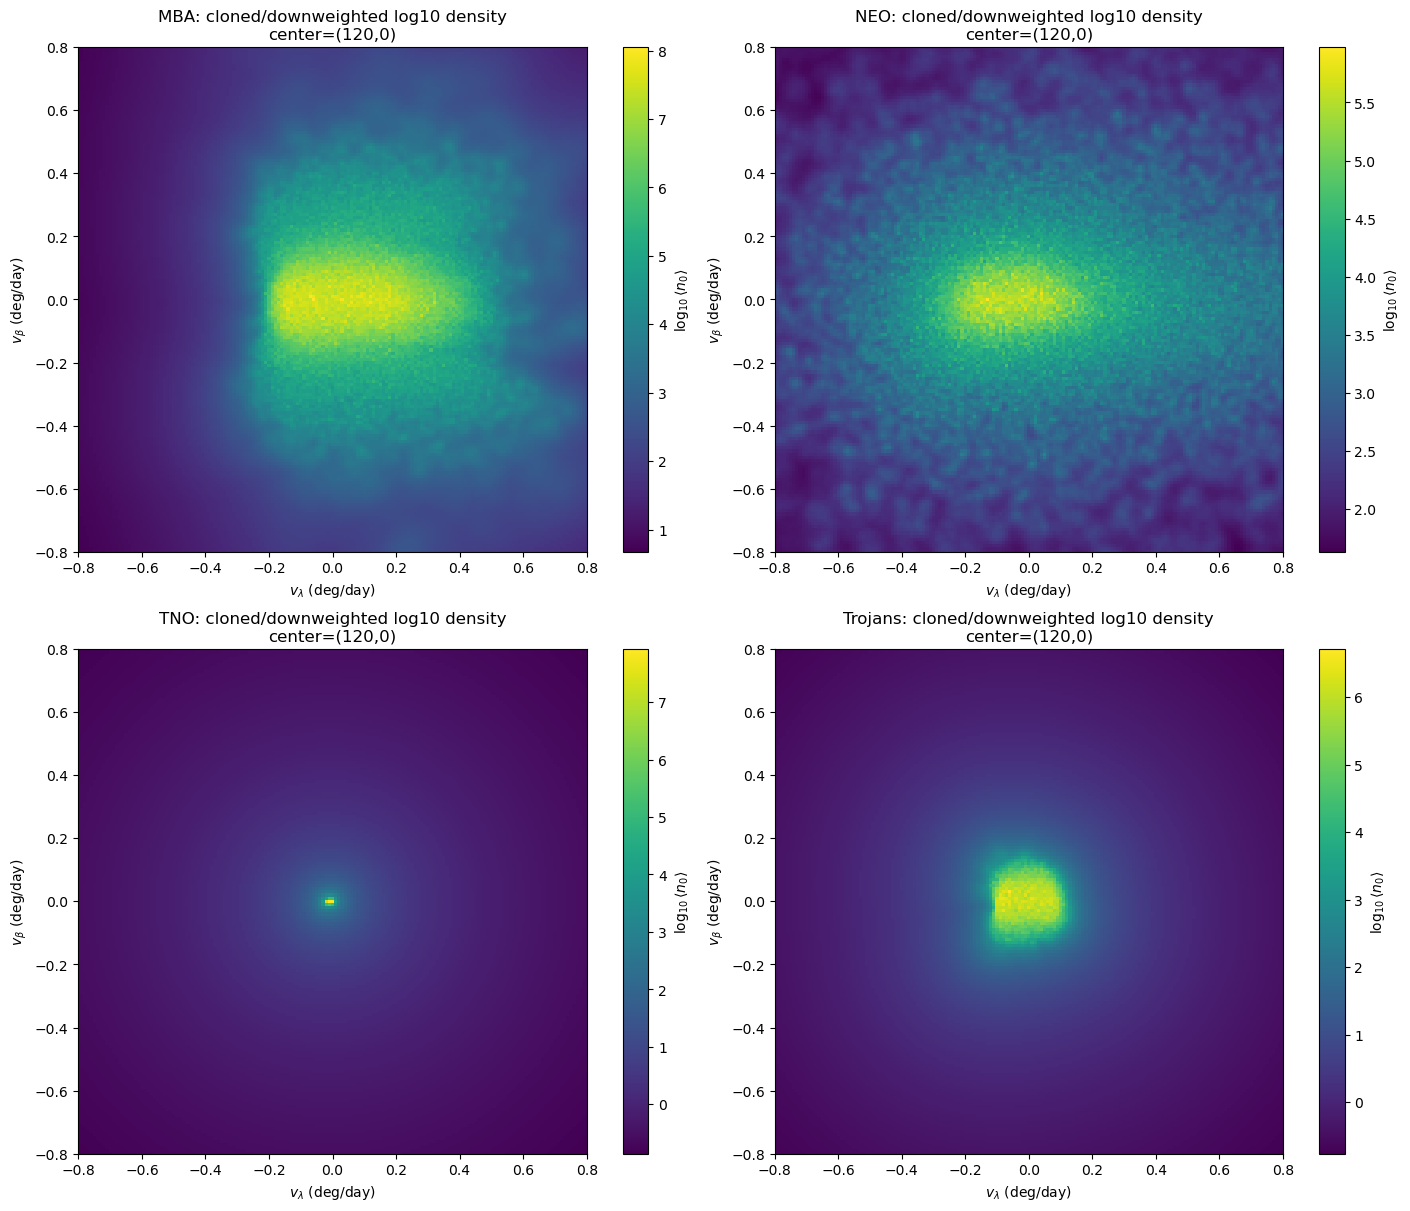

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

maps = result_lon120_lat0["density_maps_downweighted"]

for ax, pop_name in zip(axes, maps.keys()):
    log_map = np.log10(np.maximum(maps[pop_name], 1e-30))

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted log10 density\ncenter=(120,0)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$\log_{10}\langle n_0 \rangle$")

plt.show()

In [36]:
maps = result_lon120_lat0["density_maps_downweighted"]
mapsAll = maps['MBA'] + maps['NEO'] + maps['TNO'] + maps['Trojans']

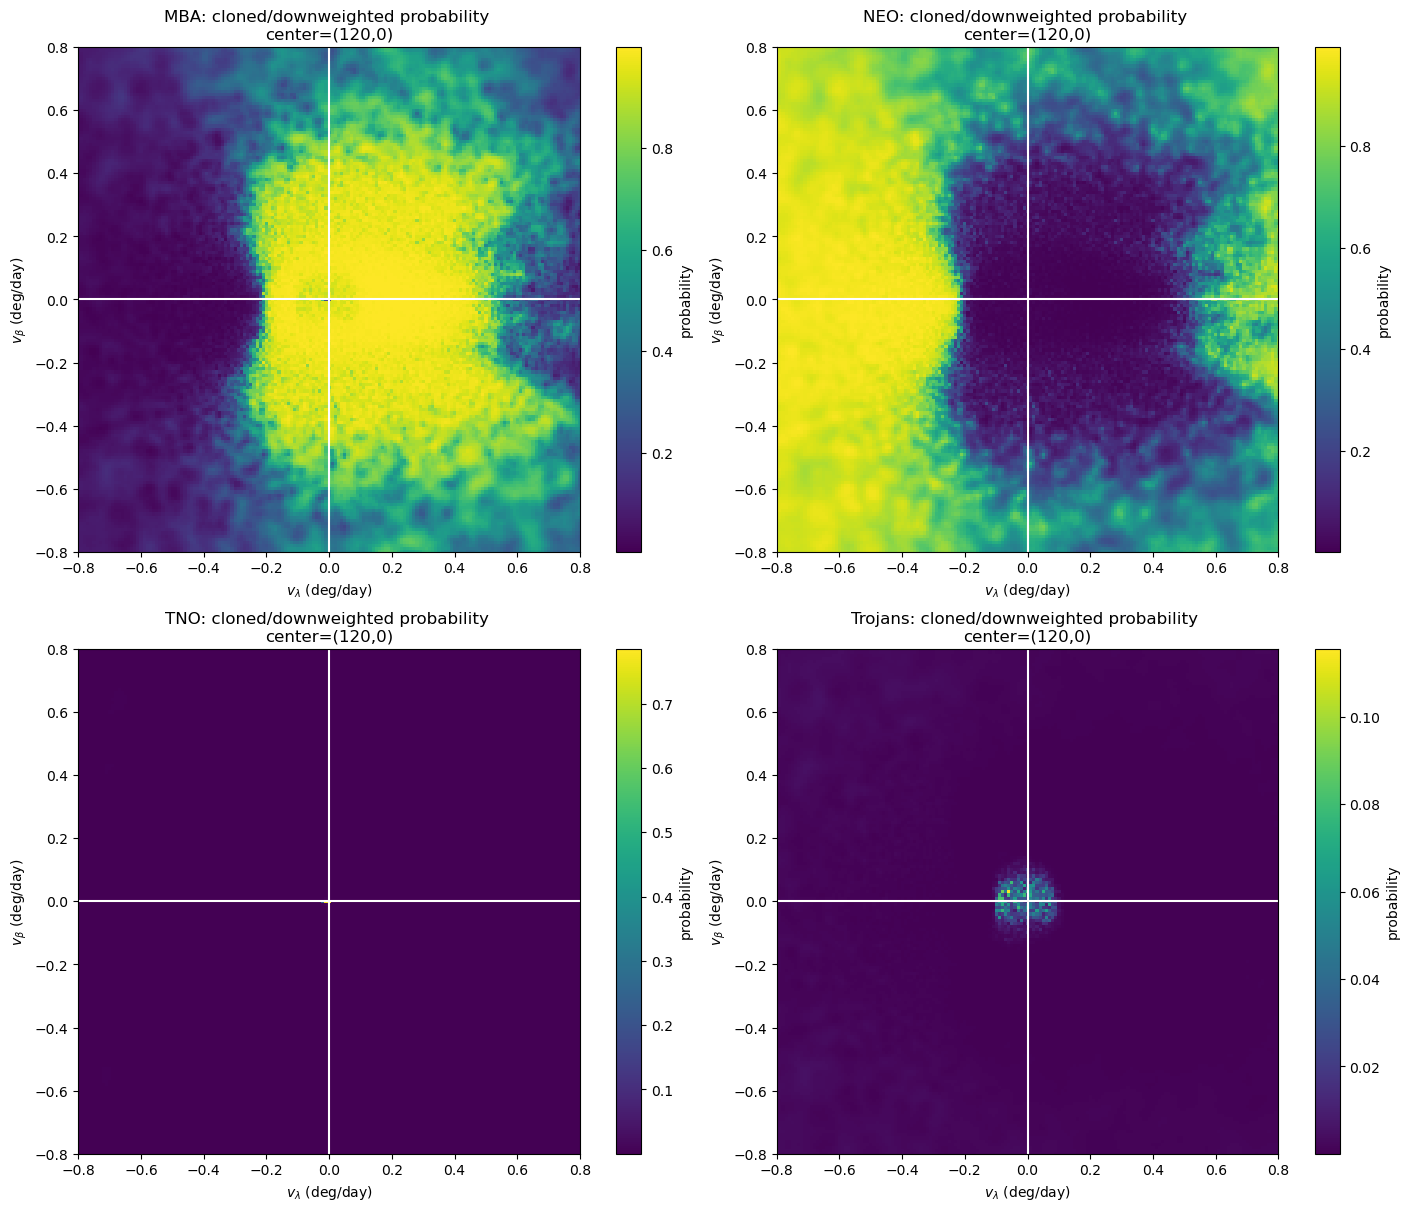

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, maps.keys()):
    log_map = maps[pop_name]/mapsAll

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted probability \ncenter=(120,0)")

    ax.plot([0, 0], [-1, 1], c='w')
    ax.plot([-1, 1], [0, 0], c='w')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"probability")

plt.show()

In [38]:
maps = clone_density_maps_downweighted
mapsAll = maps['MBA'] + maps['NEO'] + maps['TNO'] + maps['Trojans']

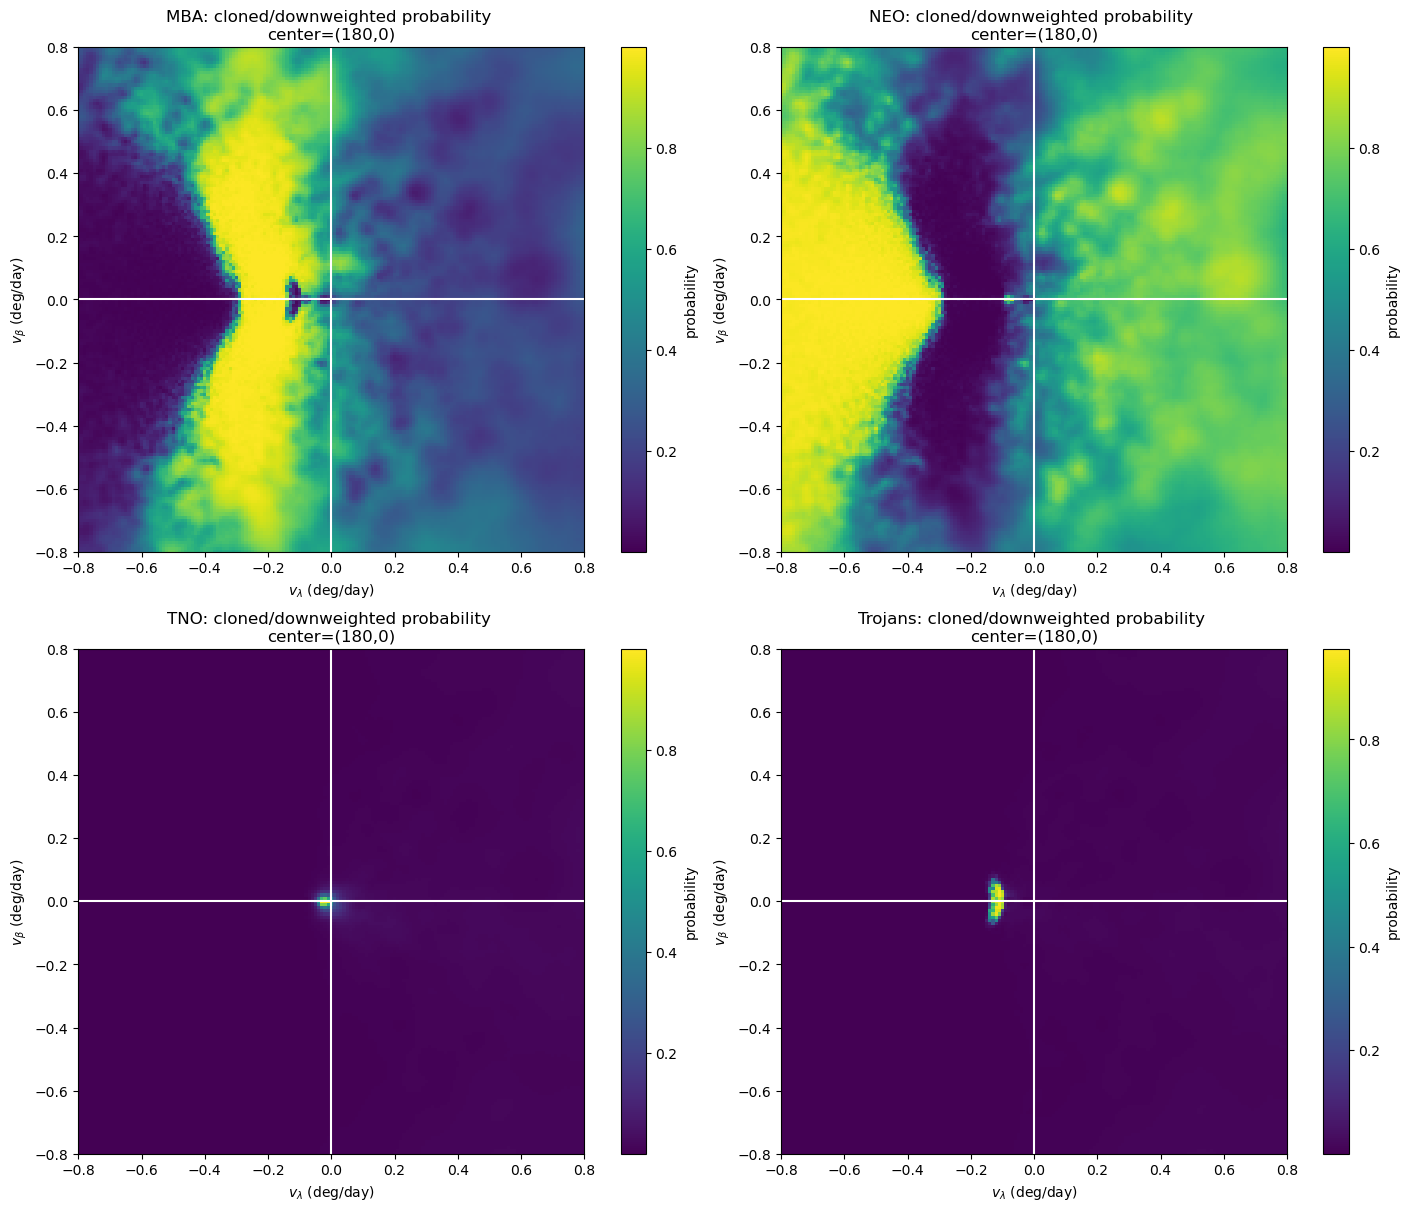

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, maps.keys()):
    log_map = maps[pop_name]/mapsAll

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted probability \ncenter=(180,0)")

    ax.plot([0, 0], [-1, 1], c='w')
    ax.plot([-1, 1], [0, 0], c='w')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"probability")

plt.show()

In [40]:
result_lon90_lat30 = build_cloned_maps_for_center(
    center_lon_deg=90.0,
    center_lat_deg=30.0,
    center_label="lon90_lat30",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon90_lat30] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 12.94it/s]


  final cloned visible points: 748084


Evaluating density map: 100%|██████████| 25921/25921 [08:03<00:00, 53.65it/s]


MBA done.
  raw cloned max density   : 82984263.99993458
  downweighted max density : 82984263.99993458

[lon90_lat30] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 48976983.96916152
  downweighted max density : 4897698.396916152

[lon90_lat30] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 13.69it/s]


  final cloned visible points: 90339


Evaluating density map: 100%|██████████| 25921/25921 [08:02<00:00, 53.71it/s]


Trojans done.
  raw cloned max density   : 17003362.9475252
  downweighted max density : 1700336.29475252


In [41]:
maps = result_lon90_lat30["density_maps_downweighted"]
mapsAll = maps['MBA'] + maps['NEO'] + maps['TNO'] + maps['Trojans']

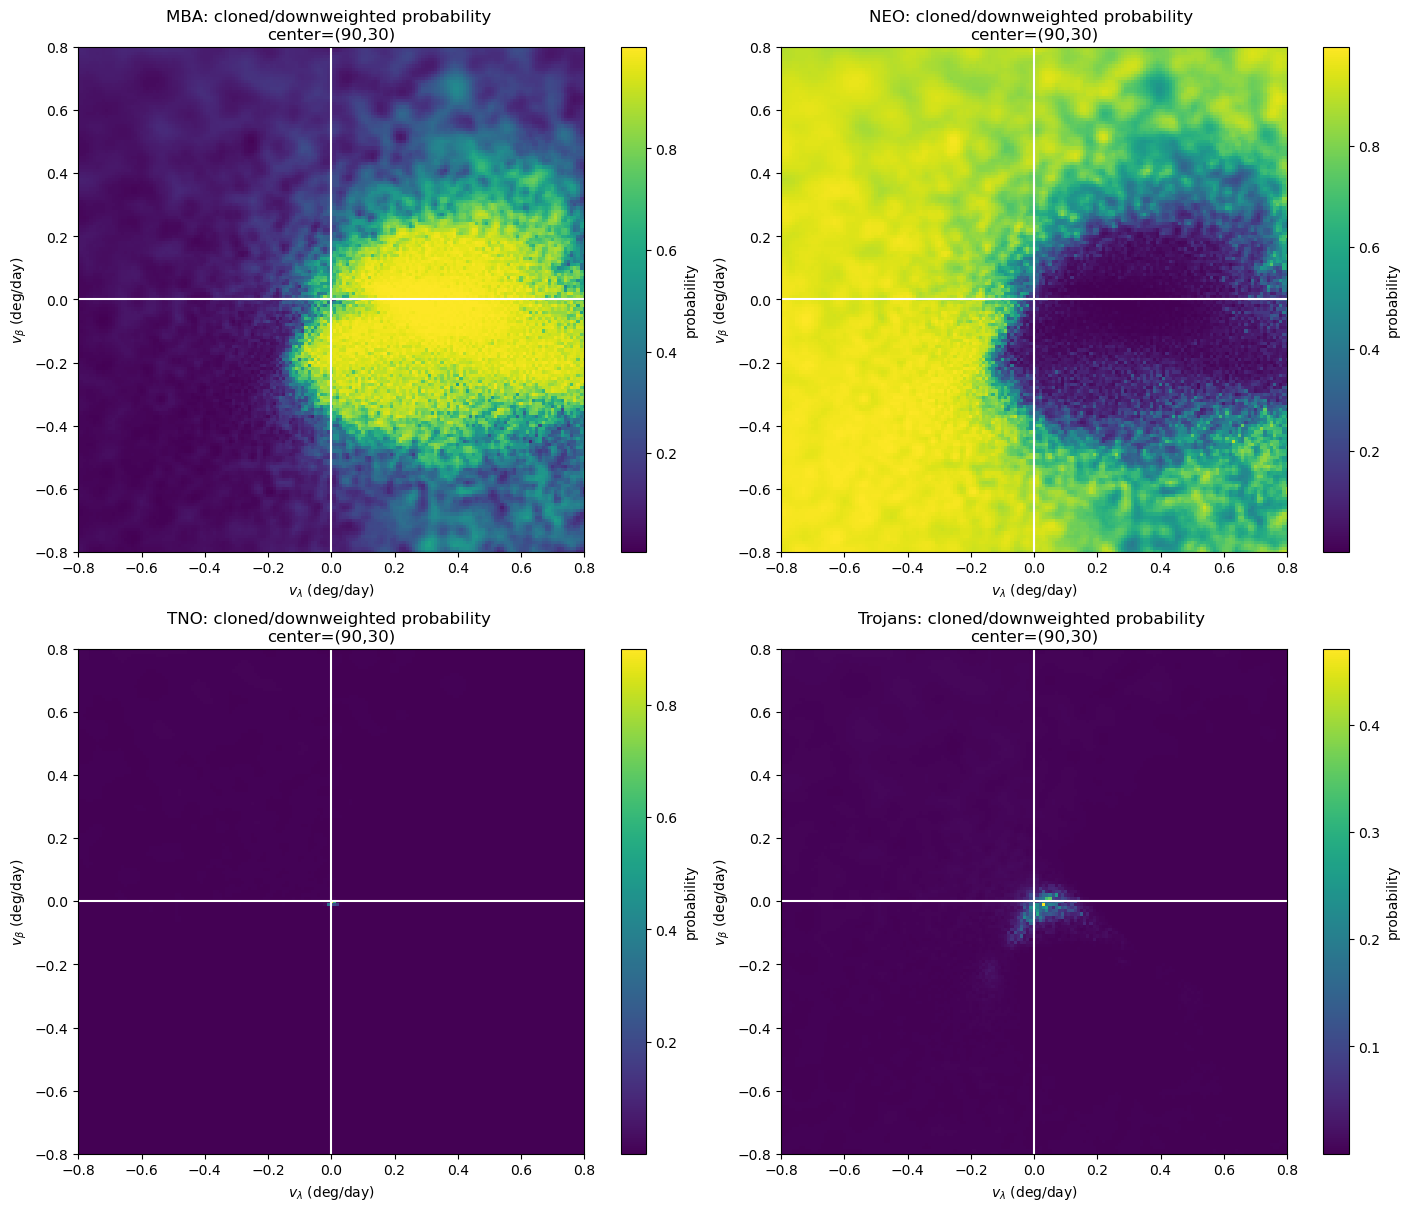

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
axes = axes.ravel()

for ax, pop_name in zip(axes, maps.keys()):
    log_map = maps[pop_name]/mapsAll

    im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xlabel(r"$v_\lambda$ (deg/day)")
    ax.set_ylabel(r"$v_\beta$ (deg/day)")
    ax.set_title(f"{pop_name}: cloned/downweighted probability \ncenter=(90,30)")

    ax.plot([0, 0], [-1, 1], c='w')
    ax.plot([-1, 1], [0, 0], c='w')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"probability")

plt.show()

In [43]:
result_lon60_lat00 = build_cloned_maps_for_center(
    center_lon_deg=60.0,
    center_lat_deg=0.0,
    center_label="lon60_lat00",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon60_lat00] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 13.18it/s]


  final cloned visible points: 2597287


Evaluating density map: 100%|██████████| 25921/25921 [08:01<00:00, 53.85it/s]


MBA done.
  raw cloned max density   : 282244676.67061234
  downweighted max density : 282244676.67061234

[lon60_lat00] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 1244950190.7882278
  downweighted max density : 124495019.07882278

[lon60_lat00] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 14.06it/s]


  final cloned visible points: 292009


Evaluating density map: 100%|██████████| 25921/25921 [07:58<00:00, 54.21it/s]


Trojans done.
  raw cloned max density   : 117929530.73723719
  downweighted max density : 11792953.073723719


In [44]:
result_lon60_lat30 = build_cloned_maps_for_center(
    center_lon_deg=60.0,
    center_lat_deg=30.0,
    center_label="lon60_lat30",
    clone_sources=clone_sources,
    obstime_str=obstime_str,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(42),
    overlay_max=overlay_max,
    grid_points=grid_points,
    X0=X0,
    k_map=k_map,
    n_d0_grid_map=n_d0_grid_map,
)


[lon60_lat30] Cloning MBA with factor 1...
  cloned orbit count: 13883361


Propagate with newton: 100%|██████████| 139/139 [00:10<00:00, 13.42it/s]


  final cloned visible points: 762487


Evaluating density map: 100%|██████████| 25921/25921 [07:58<00:00, 54.20it/s]


MBA done.
  raw cloned max density   : 85368652.24556686
  downweighted max density : 85368652.24556686

[lon60_lat30] Cloning NEO with factor 10...
  cloned orbit count: 2685110


...

TNO done.
  raw cloned max density   : 93470617.94737828
  downweighted max density : 9347061.794737827

[lon60_lat30] Cloning Trojans with factor 10...
  cloned orbit count: 1798820


Propagate with newton: 100%|██████████| 18/18 [00:01<00:00, 13.78it/s]


  final cloned visible points: 94275


Evaluating density map: 100%|██████████| 25921/25921 [07:55<00:00, 54.47it/s]


Trojans done.
  raw cloned max density   : 29685908.87368862
  downweighted max density : 2968590.887368862


In [45]:
def makeZIplots(data, longFOV, latFOV):
    maps = data["density_maps_downweighted"]
    mapsAll = maps['MBA'] + maps['NEO'] + maps['TNO'] + maps['Trojans']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)
    axes = axes.ravel()

    for ax, pop_name in zip(axes, maps.keys()):
        log_map = maps[pop_name]/mapsAll

        im = ax.pcolormesh(X0, Y0, log_map, shading="auto")

        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_xlabel(r"$v_\lambda$ (deg/day)")
        ax.set_ylabel(r"$v_\beta$ (deg/day)")
        ax.set_title(f"{pop_name}: cloned/downweighted probability \ncenter=({longFOV,latFOV})")

        ax.plot([0, 0], [-1, 1], c='w')
        ax.plot([-1, 1], [0, 0], c='w')
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label(r"probability")

    plt.show()

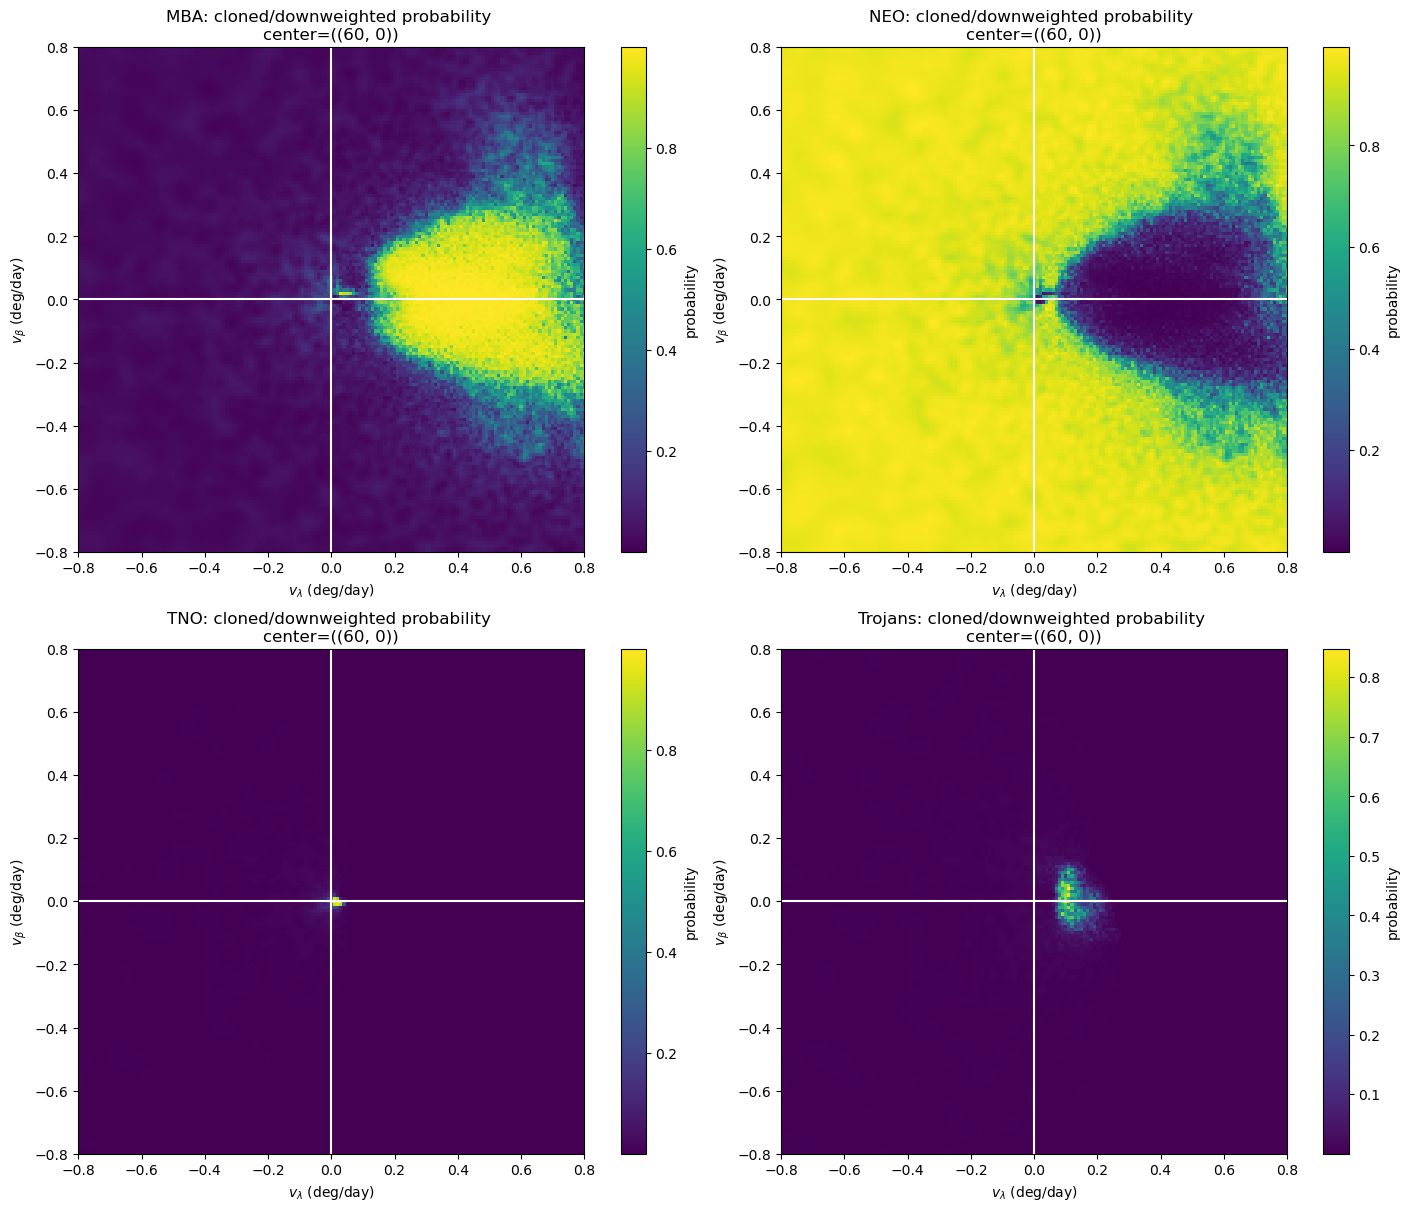

In [46]:
makeZIplots(result_lon60_lat00, 60, 0)

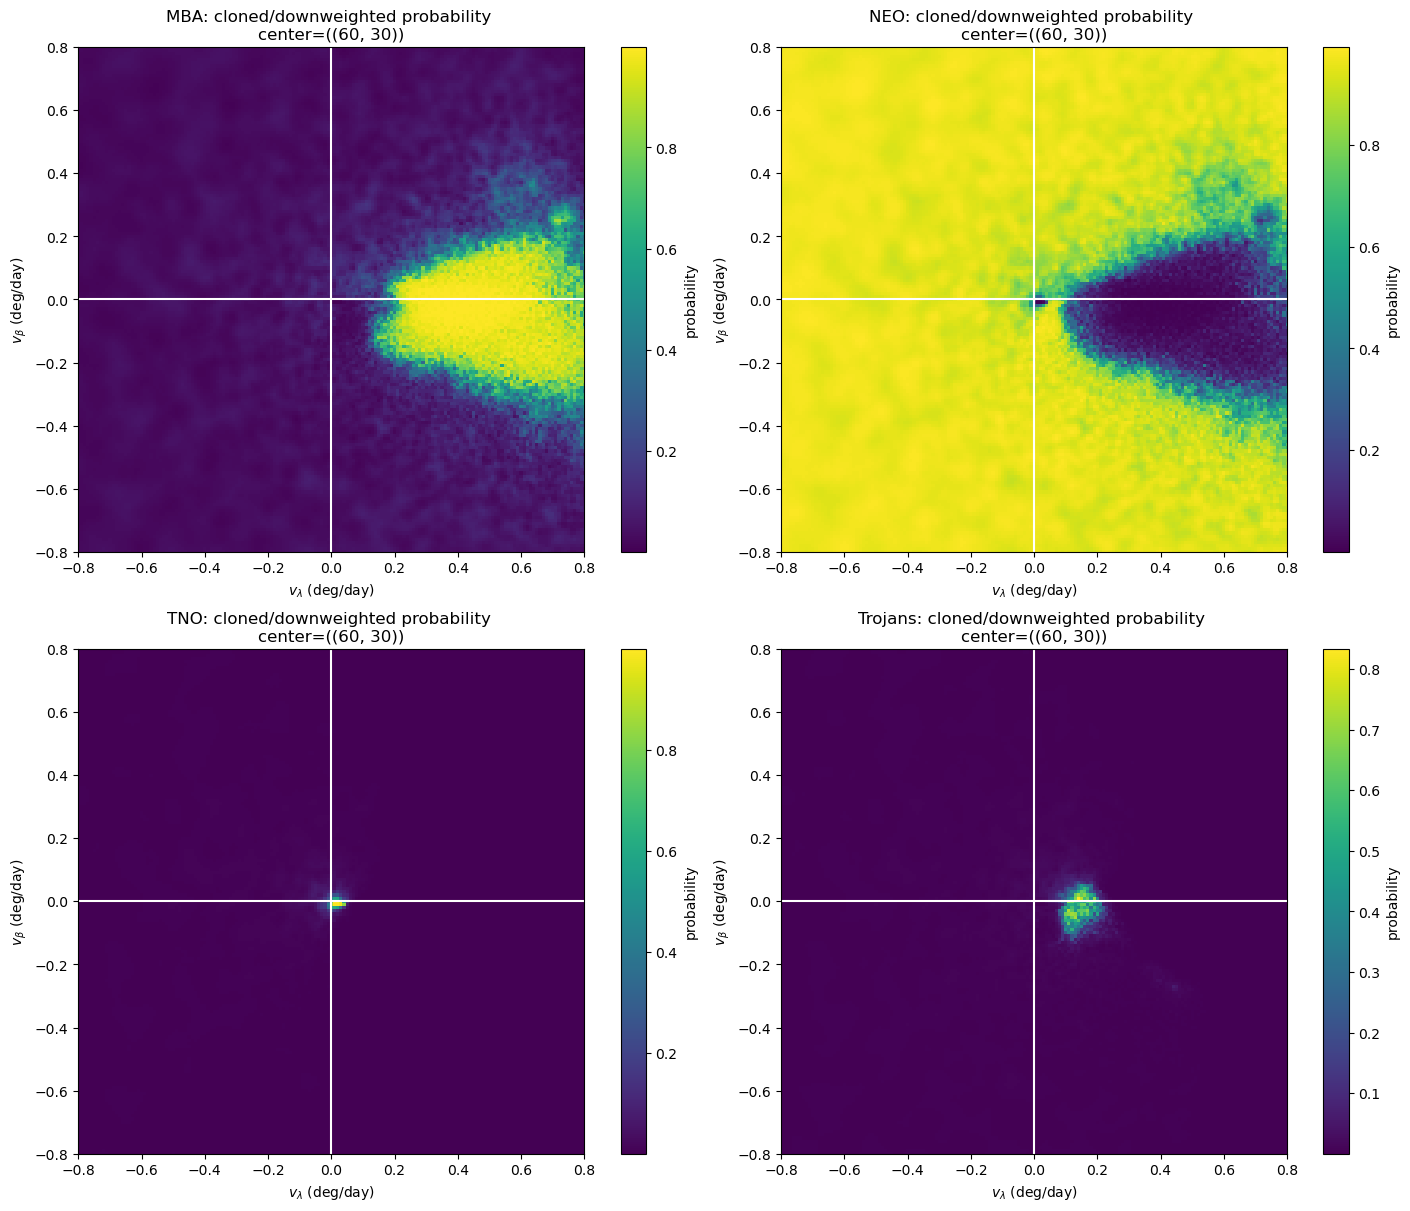

In [47]:
makeZIplots(result_lon60_lat30, 60, 30)

In [48]:
# Return lambda, beta, vlambda, vbeta for objects visible near a chosen
# ecliptic center, using the same topocentric pipeline as the code.

def elements_to_fig5_quantities(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    max_sep_deg=30.0,
    chunk=100_000,
    show_progress=True,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
):
    import astropy.units as u
    from astropy.time import Time
    from astropy.coordinates import SkyCoord, GCRS, GeocentricTrueEcliptic

    t_obs = Time(obstime_str, scale="tdb")

    #  heliocentric ecliptic state from orbital elements
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=chunk,
        show_progress=show_progress,
    )

    #  ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    #  topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    x, y, z    = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    #  RA / Dec
    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    #  angular rates
    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        np.isfinite(rho2) & np.isfinite(r2) &
        (rho2 > 0) & (r2 > 0)
    )

    ra_deg       = np.rad2deg(ra[good]) % 360.0
    dec_deg      = np.rad2deg(dec[good])
    dra_deg_day  = np.rad2deg(dra[good])  * 86400.0
    ddec_deg_day = np.rad2deg(ddec[good]) * 86400.0

    #  object sky coords in GCRS
    sc = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        frame=GCRS(obstime=t_obs)
    )

    #  center of sky cut, defined in ecliptic coordinates
    center_ecl = SkyCoord(
        lon=center_lon_deg * u.deg,
        lat=center_lat_deg * u.deg,
        distance=1.0 * u.AU,
        frame=GeocentricTrueEcliptic(obstime=t_obs),
    )
    center_sc = center_ecl.transform_to(GCRS(obstime=t_obs))

    sep = sc.separation(center_sc).deg
    m = sep <= max_sep_deg

    ra_deg       = ra_deg[m]
    dec_deg      = dec_deg[m]
    dra_deg_day  = dra_deg_day[m]
    ddec_deg_day = ddec_deg_day[m]

    #  RA/Dec -> ecliptic lambda/beta
    sc_cut = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        frame=GCRS(obstime=t_obs)
    )
    ecl = sc_cut.transform_to(GeocentricTrueEcliptic(obstime=t_obs))

    lam_deg  = ecl.lon.to_value(u.deg) % 360.0
    beta_deg = ecl.lat.to_value(u.deg)

    #  RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg,
        dec_deg,
        dra_deg_day,
        ddec_deg_day,
        obstime_str,
    )

    finite = (
        np.isfinite(lam_deg) &
        np.isfinite(beta_deg) &
        np.isfinite(vlam) &
        np.isfinite(vbeta)
    )

    return (
        lam_deg[finite].astype(np.float32),
        beta_deg[finite].astype(np.float32),
        vlam[finite].astype(np.float32),
        vbeta[finite].astype(np.float32),
    )

In [49]:
def build_fig5_overlay_for_population(
    df,
    scorer,
    clone_factor,
    obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    max_sep_deg=30.0,
    rng=None,
    chunk=100_000,
    show_progress=True,
):
    if rng is None:
        rng = np.random.default_rng(42)

    a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new = clone_population_random_mean_anomaly(
        df,
        clone_factor=clone_factor,
        obstime_str=obstime_str,
        rng=rng,
    )

    lam_deg, beta_deg, vlam, vbeta = elements_to_fig5_quantities(
        a_AU=a_rep,
        e=e_rep,
        inc=inc_rep,
        raan=raan_rep,
        argp=argp_rep,
        tp_mjd=tp_new,
        obstime_str=obstime_str,
        scorer=scorer,
        max_sep_deg=max_sep_deg,
        chunk=chunk,
        show_progress=show_progress,
        center_lon_deg=center_lon_deg,
        center_lat_deg=center_lat_deg,
    )

    return {
        "lam_deg": lam_deg,
        "beta_deg": beta_deg,
        "vlam": vlam,
        "vbeta": vbeta,
    }


rng_fig5 = np.random.default_rng(42)

fig5_mba_180_0 = build_fig5_overlay_for_population(
    df=clone_sources["MBA"]["df"],
    scorer=clone_sources["MBA"]["scorer"],
    clone_factor=clone_sources["MBA"]["clone_factor"],
    obstime_str=obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    max_sep_deg=max_sep_deg,
    rng=rng_fig5,
    chunk=100_000,
    show_progress=True,
)

fig5_neo_180_0 = build_fig5_overlay_for_population(
    df=clone_sources["NEO"]["df"],
    scorer=clone_sources["NEO"]["scorer"],
    clone_factor=clone_sources["NEO"]["clone_factor"],
    obstime_str=obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    max_sep_deg=max_sep_deg,
    rng=np.random.default_rng(43),
    chunk=100_000,
    show_progress=True,
)

print("MBA visible points:", len(fig5_mba_180_0["lam_deg"]))
print("NEO visible points:", len(fig5_neo_180_0["lam_deg"]))

Propagate with newton: 100%|██████████| 27/27 [00:01<00:00, 14.19it/s]


MBA visible points: 1418518
NEO visible points: 134463


In [50]:
def plot_fig5_mba_neo_overlay(
    mba_data,
    neo_data,
    obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    lambda_window=(150, 210),
    velocity_ylim=(-0.8, 0.8),
    beta_ylim=(-30, 30),
    max_points_mba=120_000,
    max_points_neo=25_000,
    max_points_top_mba=50_000,
    max_points_top_neo=10_000,
    reverse_x=True,
    seed=123,
):
    rng = np.random.default_rng(seed)

    def apply_window(data):
        lam   = data["lam_deg"]
        beta  = data["beta_deg"]
        vlam  = data["vlam"]
        vbeta = data["vbeta"]

        if lambda_window is not None:
            lam_lo, lam_hi = lambda_window
            m = (lam >= lam_lo) & (lam <= lam_hi)
            lam, beta, vlam, vbeta = lam[m], beta[m], vlam[m], vbeta[m]

        return lam, beta, vlam, vbeta

    def subsample_arrays(lam, beta, vlam, vbeta, nmax):
        n = len(lam)
        if n <= nmax:
            return lam, beta, vlam, vbeta
        idx = rng.choice(n, size=nmax, replace=False)
        return lam[idx], beta[idx], vlam[idx], vbeta[idx]

    # window first
    lam_mba, beta_mba, vlam_mba, vbeta_mba = apply_window(mba_data)
    lam_neo, beta_neo, vlam_neo, vbeta_neo = apply_window(neo_data)

    # separate subsamples for top panel
    lam_mba_top, beta_mba_top, _, _ = subsample_arrays(
        lam_mba, beta_mba, vlam_mba, vbeta_mba, max_points_top_mba
    )
    lam_neo_top, beta_neo_top, _, _ = subsample_arrays(
        lam_neo, beta_neo, vlam_neo, vbeta_neo, max_points_top_neo
    )

    # larger subsamples for velocity panels
    lam_mba_v, beta_mba_v, vlam_mba_v, vbeta_mba_v = subsample_arrays(
        lam_mba, beta_mba, vlam_mba, vbeta_mba, max_points_mba
    )
    lam_neo_v, beta_neo_v, vlam_neo_v, vbeta_neo_v = subsample_arrays(
        lam_neo, beta_neo, vlam_neo, vbeta_neo, max_points_neo
    )

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(8, 10),
        sharex=True,
        gridspec_kw=dict(height_ratios=[1.1, 1.0, 1.0], hspace=0.12)
    )

    
    # beta vs lambda
    # draws NEO first, MBA second
    
    ax1.scatter(lam_neo_top, beta_neo_top, s=1, alpha=0.08, label="NEO", zorder=1)
    ax1.scatter(lam_mba_top, beta_mba_top, s=1, alpha=0.25, label="MBA", zorder=2)
    ax1.axhline(0, lw=1)
    ax1.set_ylabel(r"$\beta$ (deg)")
    ax1.set_ylim(*beta_ylim)
    ax1.legend(loc="upper right")

    
    # vlambda vs lambda
    
    ax2.scatter(lam_neo_v, vlam_neo_v, s=1, alpha=0.08, zorder=1)
    ax2.scatter(lam_mba_v, vlam_mba_v, s=1, alpha=0.22, zorder=2)
    ax2.axhline(0, lw=1)
    ax2.set_ylabel(r"$v_\lambda$ (deg/day)")
    ax2.set_ylim(*velocity_ylim)

    
    # vbeta vs lambda
    
    ax3.scatter(lam_neo_v, vbeta_neo_v, s=1, alpha=0.08, zorder=1)
    ax3.scatter(lam_mba_v, vbeta_mba_v, s=1, alpha=0.22, zorder=2)
    ax3.axhline(0, lw=1)
    ax3.set_ylabel(r"$v_\beta$ (deg/day)")
    ax3.set_xlabel(r"$\lambda$ (deg)")
    ax3.set_ylim(*velocity_ylim)

    if lambda_window is None:
        ax3.set_xlim(0, 360)
    else:
        lam_lo, lam_hi = lambda_window
        ax3.set_xlim(lam_lo, lam_hi)

    if reverse_x:
        ax3.invert_xaxis()

    fig.suptitle(
        "S3M MBA + NEO Fig. 5–style plots\n"
        f"{obstime_str}   center=({center_lon_deg:.0f}°, {center_lat_deg:.0f}°)"
    )
    plt.show()

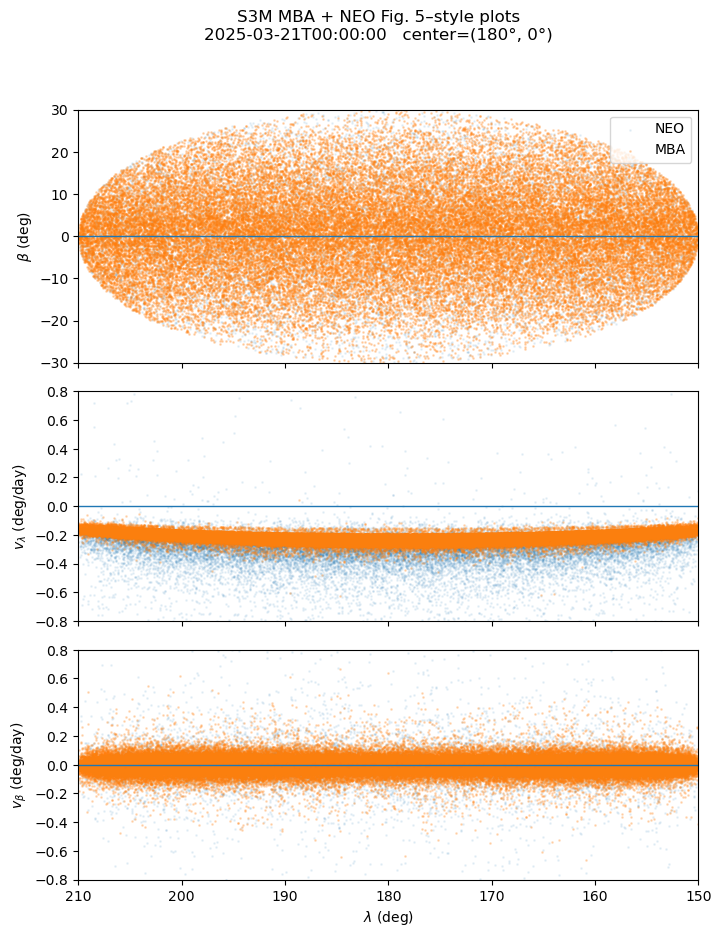

In [51]:
plot_fig5_mba_neo_overlay(
    mba_data=fig5_mba_180_0,
    neo_data=fig5_neo_180_0,
    obstime_str=obstime_str,
    center_lon_deg=180.0,
    center_lat_deg=0.0,
    lambda_window=(150, 210),
    velocity_ylim=(-0.8, 0.8),
    beta_ylim=(-30, 30),
    max_points_mba=120_000,
    max_points_neo=25_000,
    max_points_top_mba=50_000,
    max_points_top_neo=10_000,
    reverse_x=True,
)

In [52]:
def elements_to_fig5_quantities_global_chunk(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    rate_chunk=100_000,
):

    t_obs = Time(obstime_str, scale="tdb")

    # heliocentric ecliptic state from orbital elements
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=rate_chunk,
        show_progress=False,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    # free memory
    del r_obj_ecl, v_obj_ecl

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    del r_obj_helio, v_obj_helio

    x, y, z    = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    del r_rel, v_rel, x, y, z, vx, vy, vz, rho

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        np.isfinite(rho2) & np.isfinite(r2) &
        (rho2 > 0) & (r2 > 0)
    )

    del rho2, r2

    ra_deg       = (np.rad2deg(ra[good]) % 360.0).astype(np.float32)
    dec_deg      = np.rad2deg(dec[good]).astype(np.float32)
    dra_deg_day  = (np.rad2deg(dra[good])  * 86400.0).astype(np.float32)
    ddec_deg_day = (np.rad2deg(ddec[good]) * 86400.0).astype(np.float32)

    del ra, dec, dra, ddec, good

    # RA/Dec -> ecliptic lambda/beta
    sc = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        frame=GCRS(obstime=t_obs)
    )
    ecl = sc.transform_to(GeocentricTrueEcliptic(obstime=t_obs))

    lam_deg  = (ecl.lon.to_value(u.deg) % 360.0).astype(np.float32)
    beta_deg = ecl.lat.to_value(u.deg).astype(np.float32)

    # RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg,
        dec_deg,
        dra_deg_day,
        ddec_deg_day,
        obstime_str,
    )

    vlam  = np.asarray(vlam, dtype=np.float32)
    vbeta = np.asarray(vbeta, dtype=np.float32)

    finite = (
        np.isfinite(lam_deg) &
        np.isfinite(beta_deg) &
        np.isfinite(vlam) &
        np.isfinite(vbeta)
    )

    lam_deg  = lam_deg[finite]
    beta_deg = beta_deg[finite]
    vlam     = vlam[finite]
    vbeta    = vbeta[finite]

    return lam_deg, beta_deg, vlam, vbeta

In [53]:
def build_fig5_global_for_population_chunked(
    df,
    scorer,
    clone_factor,
    obstime_str,
    object_chunk=50_000,
    rate_chunk=100_000,
    beta_keep_deg=None,     
    rng=None,
    verbose=True,
):
    import gc

    if rng is None:
        rng = np.random.default_rng(42)

    n_obj = len(df)

    lam_list = []
    beta_list = []
    vlam_list = []
    vbeta_list = []

    a_all     = df["q"].to_numpy(dtype=np.float32) / (1.0 - df["e"].to_numpy(dtype=np.float32))
    e_all     = df["e"].to_numpy(dtype=np.float32)
    inc_all   = df["i"].to_numpy(dtype=np.float32)
    raan_all  = df["node"].to_numpy(dtype=np.float32)
    argp_all  = df["argperi"].to_numpy(dtype=np.float32)
    tp_all    = df["t_p"].to_numpy(dtype=np.float64)

    for i0 in range(0, n_obj, object_chunk):
        i1 = min(i0 + object_chunk, n_obj)

        if verbose:
            print(f"Objects {i0:,} to {i1:,} of {n_obj:,}")

        a_chunk    = a_all[i0:i1]
        e_chunk    = e_all[i0:i1]
        inc_chunk  = inc_all[i0:i1]
        raan_chunk = raan_all[i0:i1]
        argp_chunk = argp_all[i0:i1]
        tp_chunk   = tp_all[i0:i1]

        # clones this chunk only
        n_this = len(a_chunk)

        a_rep    = np.repeat(a_chunk, clone_factor)
        e_rep    = np.repeat(e_chunk, clone_factor)
        inc_rep  = np.repeat(inc_chunk, clone_factor)
        raan_rep = np.repeat(raan_chunk, clone_factor)
        argp_rep = np.repeat(argp_chunk, clone_factor)
        tp_rep   = np.repeat(tp_chunk, clone_factor)

        # randomize mean anomaly via new perihelion times
        # randomizes phase
        t_obs = Time(obstime_str, scale="tdb")
        AU_km_val = 149597870.7
        mu_sun_km3_s2 = 1.32712440018e11

        a_km = a_rep.astype(np.float64) * AU_km_val
        n_rad_s = np.sqrt(mu_sun_km3_s2 / (a_km**3))

        M_rand = rng.uniform(0.0, 2.0*np.pi, size=len(a_rep))
        dt_s = M_rand / n_rad_s
        tp_new = t_obs.mjd - (dt_s / 86400.0)

        lam_deg, beta_deg, vlam, vbeta = elements_to_fig5_quantities_global_chunk(
            a_AU=a_rep,
            e=e_rep,
            inc=inc_rep,
            raan=raan_rep,
            argp=argp_rep,
            tp_mjd=tp_new,
            obstime_str=obstime_str,
            scorer=scorer,
            rate_chunk=rate_chunk,
        )

        if beta_keep_deg is not None:
            m = np.abs(beta_deg) < beta_keep_deg
            lam_deg  = lam_deg[m]
            beta_deg = beta_deg[m]
            vlam     = vlam[m]
            vbeta    = vbeta[m]

        lam_list.append(lam_deg)
        beta_list.append(beta_deg)
        vlam_list.append(vlam)
        vbeta_list.append(vbeta)

        del a_chunk, e_chunk, inc_chunk, raan_chunk, argp_chunk, tp_chunk
        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_rep, tp_new
        del lam_deg, beta_deg, vlam, vbeta
        gc.collect()

    lam_all_out   = np.concatenate(lam_list).astype(np.float32)   if lam_list else np.array([], dtype=np.float32)
    beta_all_out  = np.concatenate(beta_list).astype(np.float32)  if beta_list else np.array([], dtype=np.float32)
    vlam_all_out  = np.concatenate(vlam_list).astype(np.float32)  if vlam_list else np.array([], dtype=np.float32)
    vbeta_all_out = np.concatenate(vbeta_list).astype(np.float32) if vbeta_list else np.array([], dtype=np.float32)

    return {
        "lam_deg": lam_all_out,
        "beta_deg": beta_all_out,
        "vlam": vlam_all_out,
        "vbeta": vbeta_all_out,
    }

In [54]:
fig5_mba_global_small = build_fig5_global_for_population_chunked(
    df=clone_sources["MBA"]["df"],
    scorer=clone_sources["MBA"]["scorer"],
    clone_factor=1,          # start tiny
    obstime_str=obstime_str,
    object_chunk=20_000,
    rate_chunk=50_000,
    beta_keep_deg=3.0,       # keep only what you actually need
    rng=np.random.default_rng(101),
    verbose=True,
)

fig5_neo_global_small = build_fig5_global_for_population_chunked(
    df=clone_sources["NEO"]["df"],
    scorer=clone_sources["NEO"]["scorer"],
    clone_factor=2,          # start tiny
    obstime_str=obstime_str,
    object_chunk=20_000,
    rate_chunk=50_000,
    beta_keep_deg=3.0,
    rng=np.random.default_rng(102),
    verbose=True,
)

print("MBA kept:", len(fig5_mba_global_small["lam_deg"]))
print("NEO kept:", len(fig5_neo_global_small["lam_deg"]))

Objects 0 to 20,000 of 13,883,361
Objects 20,000 to 40,000 of 13,883,361
Objects 40,000 to 60,000 of 13,883,361
Objects 60,000 to 80,000 of 13,883,361
Objects 80,000 to 100,000 of 13,883,361
Objects 100,000 to 120,000 of 13,883,361
Objects 120,000 to 140,000 of 13,883,361
Objects 140,000 to 160,000 of 13,883,361
Objects 160,000 to 180,000 of 13,883,361
Objects 180,000 to 200,000 of 13,883,361
Objects 200,000 to 220,000 of 13,883,361
Objects 220,000 to 240,000 of 13,883,361
Objects 240,000 to 260,000 of 13,883,361
Objects 260,000 to 280,000 of 13,883,361
Objects 280,000 to 300,000 of 13,883,361
Objects 300,000 to 320,000 of 13,883,361
Objects 320,000 to 340,000 of 13,883,361
Objects 340,000 to 360,000 of 13,883,361
Objects 360,000 to 380,000 of 13,883,361
Objects 380,000 to 400,000 of 13,883,361
Objects 400,000 to 420,000 of 13,883,361
Objects 420,000 to 440,000 of 13,883,361
Objects 440,000 to 460,000 of 13,883,361
Objects 460,000 to 480,000 of 13,883,361
Objects 480,000 to 500,000 of 

In [55]:
def plot_velocity_stripe_full_lambda_overlay(
    mba_data,
    neo_data,
    beta_max_deg=3.0,
    velocity_ylim=(-0.8, 0.8),
    max_points_mba=150_000,
    max_points_neo=50_000,
    seed=123,
    title="MBA + NEO velocity panels with ecliptic stripe cut",
):
    rng = np.random.default_rng(seed)

    def cut_and_sample(data, nmax):
        m = np.abs(data["beta_deg"]) < beta_max_deg

        lam   = data["lam_deg"][m]
        beta  = data["beta_deg"][m]
        vlam  = data["vlam"][m]
        vbeta = data["vbeta"][m]

        if len(lam) > nmax:
            idx = rng.choice(len(lam), size=nmax, replace=False)
            lam   = lam[idx]
            beta  = beta[idx]
            vlam  = vlam[idx]
            vbeta = vbeta[idx]

        return lam, beta, vlam, vbeta

    lam_mba, beta_mba, vlam_mba, vbeta_mba = cut_and_sample(mba_data, max_points_mba)
    lam_neo, beta_neo, vlam_neo, vbeta_neo = cut_and_sample(neo_data, max_points_neo)

    print(f"MBA after |beta| < {beta_max_deg}°:", len(lam_mba))
    print(f"NEO after |beta| < {beta_max_deg}°:", len(lam_neo))

    fig, (ax2, ax3) = plt.subplots(
        2, 1, figsize=(9, 7), sharex=True,
        gridspec_kw=dict(hspace=0.10)
    )

    # draw NEO first, MBA second
    ax2.scatter(lam_neo, vlam_neo, s=1, alpha=0.08, label="NEO", zorder=1)
    ax2.scatter(lam_mba, vlam_mba, s=1, alpha=0.20, label="MBA", zorder=2)
    ax2.axhline(0, lw=1)
    ax2.set_ylabel(r"$v_\lambda$ (deg/day)")
    ax2.set_ylim(*velocity_ylim)
    ax2.legend(loc="upper right")

    ax3.scatter(lam_neo, vbeta_neo, s=1, alpha=0.08, zorder=1)
    ax3.scatter(lam_mba, vbeta_mba, s=1, alpha=0.20, zorder=2)
    ax3.axhline(0, lw=1)
    ax3.set_ylabel(r"$v_\beta$ (deg/day)")
    ax3.set_xlabel(r"$\lambda$ (deg)")
    ax3.set_ylim(*velocity_ylim)

    # full longitude range from 360 -> 0
    ax3.set_xlim(360, 0)

    fig.suptitle(title + f"\nwith |beta| < {beta_max_deg}°")
    plt.show()

MBA after |beta| < 3.0°: 150000
NEO after |beta| < 3.0°: 50000


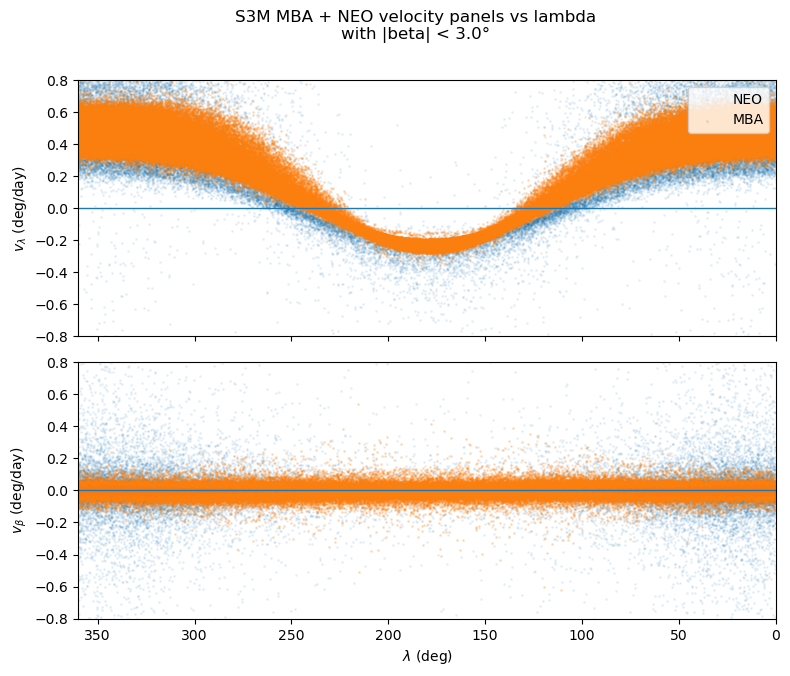

In [56]:
plot_velocity_stripe_full_lambda_overlay(
    mba_data=fig5_mba_global_small,
    neo_data=fig5_neo_global_small,
    beta_max_deg=3.0,
    velocity_ylim=(-0.8, 0.8),
    max_points_mba=150_000,
    max_points_neo=50_000,
    title="S3M MBA + NEO velocity panels vs lambda",
)

In [57]:
fig5_mba_global_top = build_fig5_global_for_population_chunked(
    df=clone_sources["MBA"]["df"],
    scorer=clone_sources["MBA"]["scorer"],
    clone_factor=1,
    obstime_str=obstime_str,
    object_chunk=20_000,
    rate_chunk=50_000,
    beta_keep_deg=None,
    rng=np.random.default_rng(201),
    verbose=True,
)

fig5_neo_global_top = build_fig5_global_for_population_chunked(
    df=clone_sources["NEO"]["df"],
    scorer=clone_sources["NEO"]["scorer"],
    clone_factor=2,
    obstime_str=obstime_str,
    object_chunk=20_000,
    rate_chunk=50_000,
    beta_keep_deg=None,
    rng=np.random.default_rng(202),
    verbose=True,
)

Objects 0 to 20,000 of 13,883,361
Objects 20,000 to 40,000 of 13,883,361
Objects 40,000 to 60,000 of 13,883,361
Objects 60,000 to 80,000 of 13,883,361
Objects 80,000 to 100,000 of 13,883,361
Objects 100,000 to 120,000 of 13,883,361
Objects 120,000 to 140,000 of 13,883,361
Objects 140,000 to 160,000 of 13,883,361
Objects 160,000 to 180,000 of 13,883,361
Objects 180,000 to 200,000 of 13,883,361
Objects 200,000 to 220,000 of 13,883,361
Objects 220,000 to 240,000 of 13,883,361
Objects 240,000 to 260,000 of 13,883,361
Objects 260,000 to 280,000 of 13,883,361
Objects 280,000 to 300,000 of 13,883,361
Objects 300,000 to 320,000 of 13,883,361
Objects 320,000 to 340,000 of 13,883,361
Objects 340,000 to 360,000 of 13,883,361
Objects 360,000 to 380,000 of 13,883,361
Objects 380,000 to 400,000 of 13,883,361
Objects 400,000 to 420,000 of 13,883,361
Objects 420,000 to 440,000 of 13,883,361
Objects 440,000 to 460,000 of 13,883,361
Objects 460,000 to 480,000 of 13,883,361
Objects 480,000 to 500,000 of 

In [58]:
def plot_fig5_global_full(
    mba_top,
    neo_top,
    beta_stripe_deg=2.5,
    velocity_ylim=(-0.8, 0.8),
    beta_ylim=(-30, 30),
    max_points_top_mba=80_000,
    max_points_top_neo=40_000,
    max_points_vel_mba=150_000,
    max_points_vel_neo=50_000,
    seed=123,
    title="S3M MBA + NEO Fig. 5–style",
):
    rng = np.random.default_rng(seed)

    
    def sample_top(data, nmax):
        lam = data["lam_deg"]
        beta = data["beta_deg"]

        if len(lam) > nmax:
            idx = rng.choice(len(lam), size=nmax, replace=False)
            lam = lam[idx]
            beta = beta[idx]

        return lam, beta

    lam_mba_top, beta_mba_top = sample_top(mba_top, max_points_top_mba)
    lam_neo_top, beta_neo_top = sample_top(neo_top, max_points_top_neo)

    
    def sample_vel(data, nmax):
        m = np.abs(data["beta_deg"]) < beta_stripe_deg

        lam   = data["lam_deg"][m]
        vlam  = data["vlam"][m]
        vbeta = data["vbeta"][m]

        if len(lam) > nmax:
            idx = rng.choice(len(lam), size=nmax, replace=False)
            lam   = lam[idx]
            vlam  = vlam[idx]
            vbeta = vbeta[idx]

        return lam, vlam, vbeta

    lam_mba_v, vlam_mba, vbeta_mba = sample_vel(mba_top, max_points_vel_mba)
    lam_neo_v, vlam_neo, vbeta_neo = sample_vel(neo_top, max_points_vel_neo)

    print(f"MBA stripe count:", len(lam_mba_v))
    print(f"NEO stripe count:", len(lam_neo_v))

    
    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(9, 10),
        sharex=True,
        gridspec_kw=dict(height_ratios=[1.1, 1.0, 1.0], hspace=0.12)
    )

    #  β vs λ  
    ax1.scatter(lam_neo_top, beta_neo_top, s=1, alpha=0.08, label="NEO", zorder=1)
    ax1.scatter(lam_mba_top, beta_mba_top, s=1, alpha=0.25, label="MBA", zorder=2)
    ax1.axhline(0, lw=1)
    ax1.set_ylabel(r"$\beta$ (deg)")
    ax1.set_ylim(*beta_ylim)
    ax1.legend(loc="upper right")

    # vλ vs λ 
    ax2.scatter(lam_neo_v, vlam_neo, s=1, alpha=0.08, zorder=1)
    ax2.scatter(lam_mba_v, vlam_mba, s=1, alpha=0.22, zorder=2)
    ax2.axhline(0, lw=1)
    ax2.set_ylabel(r"$v_\lambda$ (deg/day)")
    ax2.set_ylim(*velocity_ylim)

    #  vβ vs λ  
    ax3.scatter(lam_neo_v, vbeta_neo, s=1, alpha=0.08, zorder=1)
    ax3.scatter(lam_mba_v, vbeta_mba, s=1, alpha=0.22, zorder=2)
    ax3.axhline(0, lw=1)
    ax3.set_ylabel(r"$v_\beta$ (deg/day)")
    ax3.set_xlabel(r"$\lambda$ (deg)")
    ax3.set_ylim(*velocity_ylim)

    # full sky longitude
    ax3.set_xlim(360, 0)

    fig.suptitle(
        title + f"\nvelocity panels use |beta| < {beta_stripe_deg}°"
    )

    plt.show()

MBA stripe count: 150000
NEO stripe count: 50000


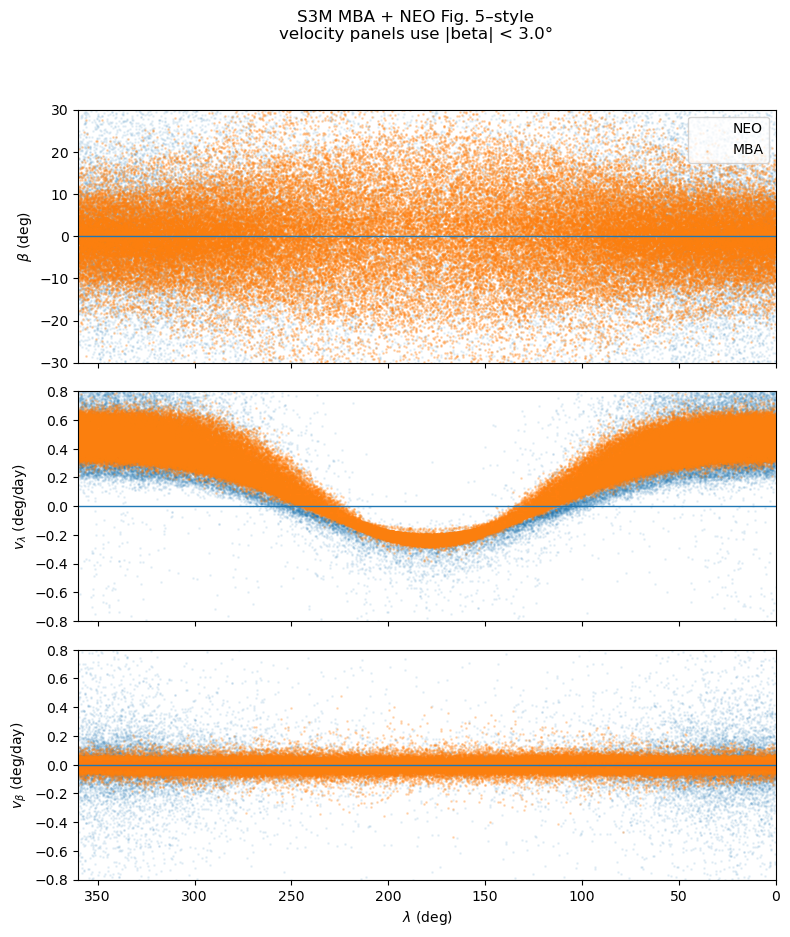

In [59]:
plot_fig5_global_full(
    mba_top=fig5_mba_global_top,
    neo_top=fig5_neo_global_top,
    beta_stripe_deg=3.0,
)

In [63]:

def elements_to_fig5_quantities_decstrip_chunk(
    a_AU, e, inc, raan, argp, tp_mjd,
    obstime_str,
    scorer,
    dec_max_deg=1.25,
    rate_chunk=100_000,
):

    t_obs = Time(obstime_str, scale="tdb")

    #  heliocentric ecliptic state from orbital elements
    r_obj_ecl, v_obj_ecl = nsc.elements_to_helio_ecliptic_state(
        a_AU=a_AU,
        e=e,
        inc_deg=inc,
        raan_deg=raan,
        argp_deg=argp,
        tp_mjd=tp_mjd,
        obstime_str=obstime_str,
        method="newton",
        n_iter=10,
        chunk=rate_chunk,
        show_progress=False,
    )

    # ecliptic -> equatorial
    eps = np.deg2rad(23.439291)
    c, s = np.cos(eps), np.sin(eps)

    r_obj_helio = np.column_stack([
        r_obj_ecl[:, 0],
        c * r_obj_ecl[:, 1] - s * r_obj_ecl[:, 2],
        s * r_obj_ecl[:, 1] + c * r_obj_ecl[:, 2],
    ])

    v_obj_helio = np.column_stack([
        v_obj_ecl[:, 0],
        c * v_obj_ecl[:, 1] - s * v_obj_ecl[:, 2],
        s * v_obj_ecl[:, 1] + c * v_obj_ecl[:, 2],
    ])

    del r_obj_ecl, v_obj_ecl

    # observer state
    _, rE, vE, r_tele = scorer._get_earth_and_observer(obstime_str)

    # topocentric relative vectors
    r_rel = r_obj_helio - (rE + r_tele)
    v_rel = v_obj_helio - vE

    del r_obj_helio, v_obj_helio

    # Cartesian -> RA, Dec and rates
    x, y, z    = r_rel[:, 0], r_rel[:, 1], r_rel[:, 2]
    vx, vy, vz = v_rel[:, 0], v_rel[:, 1], v_rel[:, 2]

    rho2 = x*x + y*y
    r2   = rho2 + z*z
    rho  = np.sqrt(rho2)

    ra  = np.arctan2(y, x)
    dec = np.arctan2(z, rho)

    dra  = (x*vy - y*vx) / rho2
    ddec = (vz*rho2 - z*(x*vx + y*vy)) / (r2 * rho)

    good = (
        np.isfinite(ra) & np.isfinite(dec) &
        np.isfinite(dra) & np.isfinite(ddec) &
        np.isfinite(rho2) & np.isfinite(r2) &
        (rho2 > 0) & (r2 > 0)
    )

    ra_deg       = (np.rad2deg(ra[good]) % 360.0).astype(np.float32)
    dec_deg      = np.rad2deg(dec[good]).astype(np.float32)
    dra_deg_day  = (np.rad2deg(dra[good])  * 86400.0).astype(np.float32)
    ddec_deg_day = (np.rad2deg(ddec[good]) * 86400.0).astype(np.float32)

    del r_rel, v_rel, x, y, z, vx, vy, vz, rho2, r2, rho, ra, dec, dra, ddec, good

    # fig 5. similar cut
    m_dec = (dec_deg > -dec_max_deg) & (dec_deg < dec_max_deg)

    ra_deg       = ra_deg[m_dec]
    dec_deg      = dec_deg[m_dec]
    dra_deg_day  = dra_deg_day[m_dec]
    ddec_deg_day = ddec_deg_day[m_dec]

    if len(ra_deg) == 0:
        empty = np.array([], dtype=np.float32)
        return empty, empty, empty, empty

    # convert surviving objects to ecliptic lambda, beta
    sc = SkyCoord(
        ra=ra_deg * u.deg,
        dec=dec_deg * u.deg,
        frame=GCRS(obstime=t_obs)
    )
    ecl = sc.transform_to(GeocentricTrueEcliptic(obstime=t_obs))

    lam_deg  = (ecl.lon.to_value(u.deg) % 360.0).astype(np.float32)
    beta_deg = ecl.lat.to_value(u.deg).astype(np.float32)

    # convert RA/Dec rates -> ecliptic rates
    vlam, vbeta = nsc.radec_rates_to_ecliptic_rates_at_obstime(
        ra_deg,
        dec_deg,
        dra_deg_day,
        ddec_deg_day,
        obstime_str,
    )

    vlam  = np.asarray(vlam, dtype=np.float32)
    vbeta = np.asarray(vbeta, dtype=np.float32)

    finite = (
        np.isfinite(lam_deg) &
        np.isfinite(beta_deg) &
        np.isfinite(vlam) &
        np.isfinite(vbeta)
    )

    return lam_deg[finite], beta_deg[finite], vlam[finite], vbeta[finite]


def build_fig5_decstrip_for_population_chunked(
    df,
    scorer,
    clone_factor,
    obstime_str,
    dec_max_deg=1.25,
    object_chunk=50_000,
    rate_chunk=100_000,
    rng=None,
    verbose=True,
):
    import gc
    from astropy.time import Time

    if rng is None:
        rng = np.random.default_rng(42)

    n_obj = len(df)

    lam_list = []
    beta_list = []
    vlam_list = []
    vbeta_list = []

    a_all     = df["q"].to_numpy(dtype=np.float32) / (1.0 - df["e"].to_numpy(dtype=np.float32))
    e_all     = df["e"].to_numpy(dtype=np.float32)
    inc_all   = df["i"].to_numpy(dtype=np.float32)
    raan_all  = df["node"].to_numpy(dtype=np.float32)
    argp_all  = df["argperi"].to_numpy(dtype=np.float32)
    tp_all    = df["t_p"].to_numpy(dtype=np.float64)

    t_obs = Time(obstime_str, scale="tdb")
    AU_km_val = 149597870.7
    mu_sun_km3_s2 = 1.32712440018e11

    for i0 in range(0, n_obj, object_chunk):
        i1 = min(i0 + object_chunk, n_obj)

        if verbose:
            print(f"Objects {i0:,} to {i1:,} of {n_obj:,}")

        a_chunk    = a_all[i0:i1]
        e_chunk    = e_all[i0:i1]
        inc_chunk  = inc_all[i0:i1]
        raan_chunk = raan_all[i0:i1]
        argp_chunk = argp_all[i0:i1]
        tp_chunk   = tp_all[i0:i1]

        # clone this chunk only
        a_rep    = np.repeat(a_chunk, clone_factor)
        e_rep    = np.repeat(e_chunk, clone_factor)
        inc_rep  = np.repeat(inc_chunk, clone_factor)
        raan_rep = np.repeat(raan_chunk, clone_factor)
        argp_rep = np.repeat(argp_chunk, clone_factor)

        # randomize mean anomaly via perihelion-time shift
        a_km = a_rep.astype(np.float64) * AU_km_val
        n_rad_s = np.sqrt(mu_sun_km3_s2 / (a_km**3))
        M_rand = rng.uniform(0.0, 2.0*np.pi, size=len(a_rep))
        dt_s = M_rand / n_rad_s
        tp_new = t_obs.mjd - (dt_s / 86400.0)

        lam_deg, beta_deg, vlam, vbeta = elements_to_fig5_quantities_decstrip_chunk(
            a_AU=a_rep,
            e=e_rep,
            inc=inc_rep,
            raan=raan_rep,
            argp=argp_rep,
            tp_mjd=tp_new,
            obstime_str=obstime_str,
            scorer=scorer,
            dec_max_deg=dec_max_deg,
            rate_chunk=rate_chunk,
        )

        lam_list.append(lam_deg)
        beta_list.append(beta_deg)
        vlam_list.append(vlam)
        vbeta_list.append(vbeta)

        del a_chunk, e_chunk, inc_chunk, raan_chunk, argp_chunk, tp_chunk
        del a_rep, e_rep, inc_rep, raan_rep, argp_rep, tp_new
        del lam_deg, beta_deg, vlam, vbeta
        gc.collect()

    lam_all_out   = np.concatenate(lam_list).astype(np.float32)   if lam_list else np.array([], dtype=np.float32)
    beta_all_out  = np.concatenate(beta_list).astype(np.float32)  if beta_list else np.array([], dtype=np.float32)
    vlam_all_out  = np.concatenate(vlam_list).astype(np.float32)  if vlam_list else np.array([], dtype=np.float32)
    vbeta_all_out = np.concatenate(vbeta_list).astype(np.float32) if vbeta_list else np.array([], dtype=np.float32)

    return {
        "lam_deg": lam_all_out,
        "beta_deg": beta_all_out,
        "vlam": vlam_all_out,
        "vbeta": vbeta_all_out,
    }


def plot_fig5_decstrip(
    mba_data,
    neo_data,
    dec_max_deg=1.25,
    lam_window=(120.0, 240.0),
    beta_ylim=(-30, 30),
    vlam_ylim=(-0.5, 0.3),
    vbeta_ylim=(-0.3, 0.3),
    max_points_mba=150_000,
    max_points_neo=50_000,
    seed=123,
    title="S3M MBA + NEO Fig. 5-style",
):
    rng = np.random.default_rng(seed)

    def window_and_sample(data, nmax):
        lam   = data["lam_deg"]
        beta  = data["beta_deg"]
        vlam  = data["vlam"]
        vbeta = data["vbeta"]

        lam_lo, lam_hi = lam_window
        m = (lam >= lam_lo) & (lam <= lam_hi)

        lam   = lam[m]
        beta  = beta[m]
        vlam  = vlam[m]
        vbeta = vbeta[m]

        if len(lam) > nmax:
            idx = rng.choice(len(lam), size=nmax, replace=False)
            lam   = lam[idx]
            beta  = beta[idx]
            vlam  = vlam[idx]
            vbeta = vbeta[idx]

        return lam, beta, vlam, vbeta

    lam_mba, beta_mba, vlam_mba, vbeta_mba = window_and_sample(mba_data, max_points_mba)
    lam_neo, beta_neo, vlam_neo, vbeta_neo = window_and_sample(neo_data, max_points_neo)

    print(f"MBA in window: {len(lam_mba)}")
    print(f"NEO in window: {len(lam_neo)}")

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(8, 10),
        sharex=True,
        gridspec_kw=dict(height_ratios=[1.1, 1.0, 1.0], hspace=0.12)
    )

    # beta vs lambda
    ax1.scatter(lam_neo, beta_neo, s=1, alpha=0.08, label="NEO", zorder=1)
    ax1.scatter(lam_mba, beta_mba, s=1, alpha=0.22, label="MBA", zorder=2)
    ax1.axhline(0, lw=1)
    ax1.set_ylabel(r"$\beta$ (deg)")
    ax1.set_ylim(*beta_ylim)
    ax1.legend(loc="upper right")

    # v_lambda vs lambda
    ax2.scatter(lam_neo, vlam_neo, s=1, alpha=0.08, zorder=1)
    ax2.scatter(lam_mba, vlam_mba, s=1, alpha=0.22, zorder=2)
    ax2.axhline(0, lw=1)
    ax2.set_ylabel(r"$v_\lambda$ (deg/day)")
    ax2.set_ylim(*vlam_ylim)

    # v_beta vs lambda
    ax3.scatter(lam_neo, vbeta_neo, s=1, alpha=0.08, zorder=1)
    ax3.scatter(lam_mba, vbeta_mba, s=1, alpha=0.22, zorder=2)
    ax3.axhline(0, lw=1)
    ax3.set_ylabel(r"$v_\beta$ (deg/day)")
    ax3.set_xlabel(r"$\lambda$ (deg)")
    ax3.set_ylim(*vbeta_ylim)

    ax3.set_xlim(240, 120)

    fig.suptitle(
        title + f"\nwith |Dec| < {dec_max_deg}°"
    )
    plt.show()

In [61]:
fig5_mba_decstrip = build_fig5_decstrip_for_population_chunked(
    df=clone_sources["MBA"]["df"],
    scorer=clone_sources["MBA"]["scorer"],
    clone_factor=1,
    obstime_str=obstime_str,
    dec_max_deg=1.25,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(301),
    verbose=True,
)

fig5_neo_decstrip = build_fig5_decstrip_for_population_chunked(
    df=clone_sources["NEO"]["df"],
    scorer=clone_sources["NEO"]["scorer"],
    clone_factor=2,
    obstime_str=obstime_str,
    dec_max_deg=1.25,
    object_chunk=20_000,
    rate_chunk=50_000,
    rng=np.random.default_rng(302),
    verbose=True,
)

Objects 0 to 20,000 of 13,883,361
Objects 20,000 to 40,000 of 13,883,361
Objects 40,000 to 60,000 of 13,883,361
Objects 60,000 to 80,000 of 13,883,361
Objects 80,000 to 100,000 of 13,883,361
Objects 100,000 to 120,000 of 13,883,361
Objects 120,000 to 140,000 of 13,883,361
Objects 140,000 to 160,000 of 13,883,361
Objects 160,000 to 180,000 of 13,883,361
Objects 180,000 to 200,000 of 13,883,361
Objects 200,000 to 220,000 of 13,883,361
Objects 220,000 to 240,000 of 13,883,361
Objects 240,000 to 260,000 of 13,883,361
Objects 260,000 to 280,000 of 13,883,361
Objects 280,000 to 300,000 of 13,883,361
Objects 300,000 to 320,000 of 13,883,361
Objects 320,000 to 340,000 of 13,883,361
Objects 340,000 to 360,000 of 13,883,361
Objects 360,000 to 380,000 of 13,883,361
Objects 380,000 to 400,000 of 13,883,361
Objects 400,000 to 420,000 of 13,883,361
Objects 420,000 to 440,000 of 13,883,361
Objects 440,000 to 460,000 of 13,883,361
Objects 460,000 to 480,000 of 13,883,361
Objects 480,000 to 500,000 of 

MBA in window: 150000
NEO in window: 3292


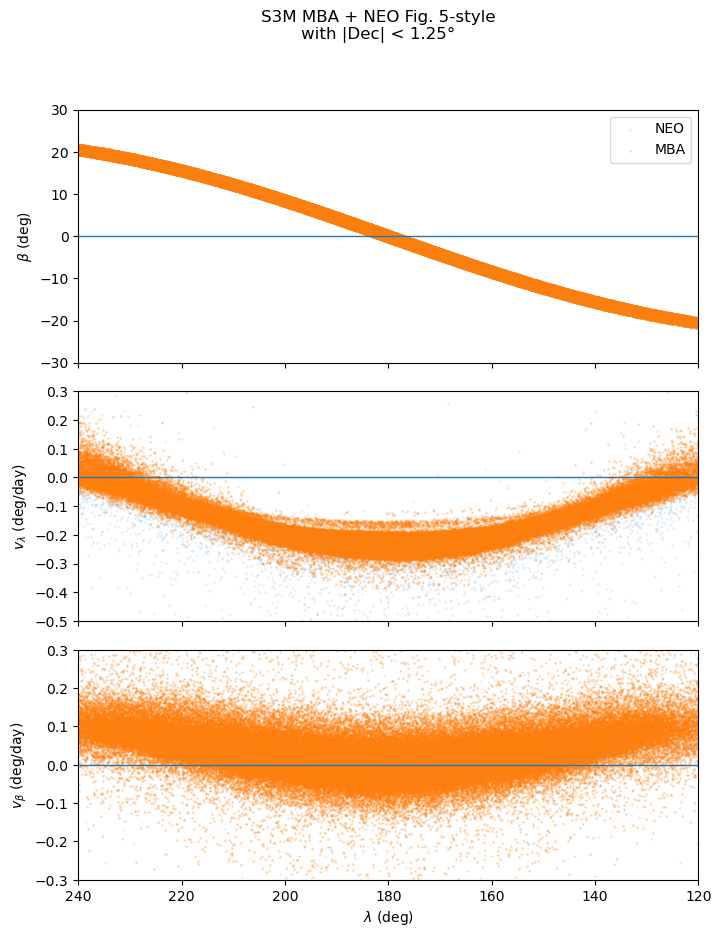

In [62]:
plot_fig5_decstrip(
    mba_data=fig5_mba_decstrip,
    neo_data=fig5_neo_decstrip,
    dec_max_deg=1.25,
    lam_window=(120.0, 240.0),
    beta_ylim=(-30, 30),
    vlam_ylim=(-0.5, 0.3),
    vbeta_ylim=(-0.3, 0.3),
    max_points_mba=150_000,
    max_points_neo=50_000,
    title="S3M MBA + NEO Fig. 5-style",
)

In [64]:
def plot_fig5_single_population(
    data,
    label="MBA",
    dec_max_deg=1.25,
    lam_window=(120.0, 240.0),
    beta_ylim=(-30, 30),
    vlam_ylim=(-0.5, 0.3),
    vbeta_ylim=(-0.3, 0.3),
    max_points=150_000,
    seed=123,
    title="Fig. 5-style",
):
    rng = np.random.default_rng(seed)

    lam   = data["lam_deg"]
    beta  = data["beta_deg"]
    vlam  = data["vlam"]
    vbeta = data["vbeta"]

    lam_lo, lam_hi = lam_window
    m = (lam >= lam_lo) & (lam <= lam_hi)

    lam   = lam[m]
    beta  = beta[m]
    vlam  = vlam[m]
    vbeta = vbeta[m]

    print(f"{label} in window:", len(lam))

    if len(lam) > max_points:
        idx = rng.choice(len(lam), size=max_points, replace=False)
        lam   = lam[idx]
        beta  = beta[idx]
        vlam  = vlam[idx]
        vbeta = vbeta[idx]

    fig, (ax1, ax2, ax3) = plt.subplots(
        3, 1,
        figsize=(8, 10),
        sharex=True,
        gridspec_kw=dict(height_ratios=[1.1, 1.0, 1.0], hspace=0.12)
    )

    # beta vs lambda
    ax1.scatter(lam, beta, s=1, alpha=0.22, label=label)
    ax1.axhline(0, lw=1)
    ax1.set_ylabel(r"$\beta$ (deg)")
    ax1.set_ylim(*beta_ylim)
    ax1.legend(loc="upper right")

    # v_lambda vs lambda
    ax2.scatter(lam, vlam, s=1, alpha=0.22)
    ax2.axhline(0, lw=1)
    ax2.set_ylabel(r"$v_\lambda$ (deg/day)")
    ax2.set_ylim(*vlam_ylim)

    # v_beta vs lambda
    ax3.scatter(lam, vbeta, s=1, alpha=0.22)
    ax3.axhline(0, lw=1)
    ax3.set_ylabel(r"$v_\beta$ (deg/day)")
    ax3.set_xlabel(r"$\lambda$ (deg)")
    ax3.set_ylim(*vbeta_ylim)

    ax3.set_xlim(240, 120)

    fig.suptitle(title + f"\n{label} only, with |Dec| < {dec_max_deg}°")
    plt.show()

MBA in window: 168516


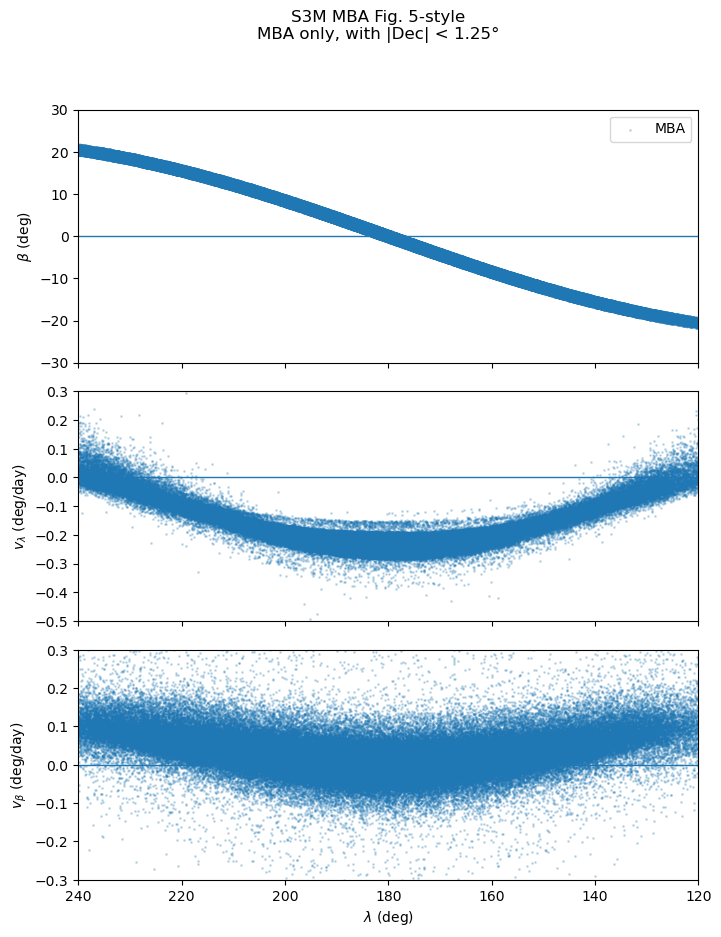

In [65]:
plot_fig5_single_population(
    data=fig5_mba_decstrip,
    label="MBA",
    dec_max_deg=1.25,
    lam_window=(120.0, 240.0),
    beta_ylim=(-30, 30),
    vlam_ylim=(-0.5, 0.3),
    vbeta_ylim=(-0.3, 0.3),
    max_points=150_000,
    seed=401,
    title="S3M MBA Fig. 5-style",
)

NEO in window: 3292


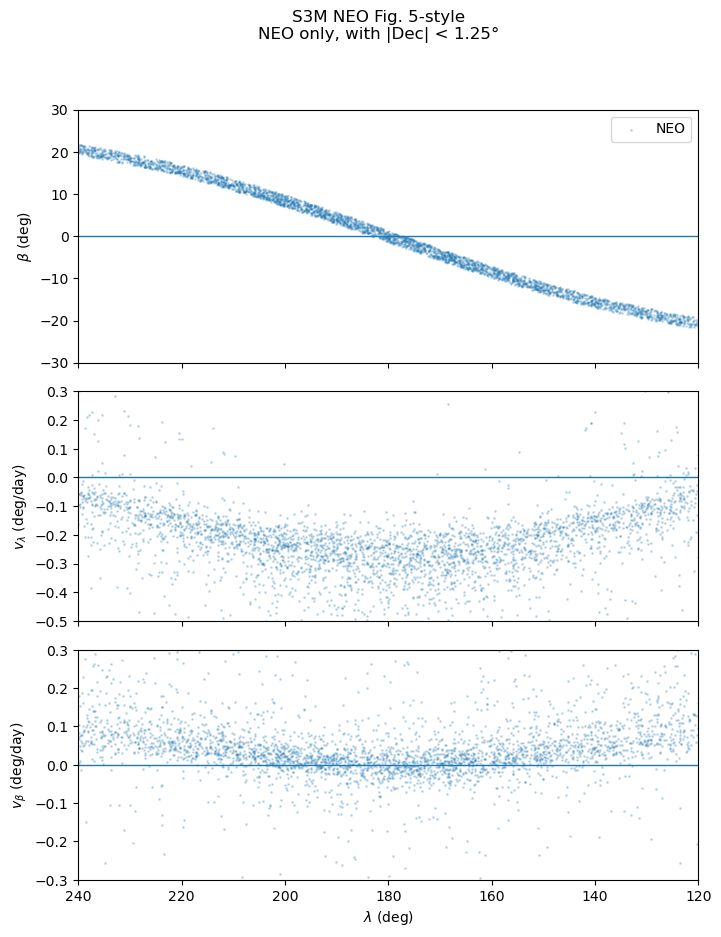

In [66]:
plot_fig5_single_population(
    data=fig5_neo_decstrip,
    label="NEO",
    dec_max_deg=1.25,
    lam_window=(120.0, 240.0),
    beta_ylim=(-30, 30),
    vlam_ylim=(-0.5, 0.3),
    vbeta_ylim=(-0.3, 0.3),
    max_points=150_000,
    seed=402,
    title="S3M NEO Fig. 5-style",
)